# Data Study

## Halogen Lamp Dataset








### False Trip

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Halogen Lamp dataset"
EXCEL_FILE = "Halogen_Lamp_(FalseTrip).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 19744, 20000, -1, None, None)       # Trial 0: No custom graph

}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()


### Model A

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Halogen Lamp dataset"
EXCEL_FILE = "Halogen_Lamp_(Model_A).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 19744, 20000, -1, None, None),       # Trial 0: No custom graph
    1: (0, 19894, 20150, -1, None, None),     # Trial 1: Custom graph from index 10k to 12k
    2: (0, 9594, 9850, 15400, None, None),      # Trial 2
    3: (0, 15094, 15350, 20950, None, None),    # Trial 3
    4: (0, 16744, 17000, 22400, None, None)     # Trial 4
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()


### Model B

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Halogen Lamp dataset"
EXCEL_FILE = "Halogen_Lamp_(Model_B).xlsx"

TRIAL_INDICES = {
    0: (0, 18544, 18800, 25050, None, None),
    1: (0, 20844, 21100, -1, None, None),
    2: (0, 19644, 19900, -1, None, None),
    3: (0, 19994, 20250, -1, None, None),
    4: (0, 20244, 20500, -1, None, None)
}

MAX_PLOT_POINTS = 4000
MAX_SPECTROGRAM_INPUT = 200_000
import plotly.io as pio
pio.renderers.default = "colab"
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V7 — memory/render optimized, Colab-safe)
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import rfft, rfftfreq
from scipy.signal import spectrogram
from scipy.ndimage import uniform_filter1d
import ipywidgets as widgets
from IPython.display import display, clear_output

file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()

_signal_cache = {}

def get_signal(trial_idx):
    if trial_idx not in _signal_cache:
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values.astype(np.float32)
        _signal_cache[trial_idx] = sig
    return _signal_cache[trial_idx]


def minmax_downsample(y, target_points=MAX_PLOT_POINTS):
    n = len(y)
    if n <= target_points:
        return np.arange(n), y
    n_buckets = max(1, target_points // 2)
    edges = np.linspace(0, n, n_buckets + 1).astype(int)
    xs = np.empty(n_buckets * 2, dtype=np.int64)
    ys = np.empty(n_buckets * 2, dtype=y.dtype)
    for i in range(n_buckets):
        start, end = edges[i], edges[i + 1]
        if end <= start:
            end = start + 1
        chunk = y[start:end]
        idx_min = start + int(np.argmin(chunk))
        idx_max = start + int(np.argmax(chunk))
        if idx_min <= idx_max:
            xs[2*i], xs[2*i+1] = idx_min, idx_max
            ys[2*i], ys[2*i+1] = y[idx_min], y[idx_max]
        else:
            xs[2*i], xs[2*i+1] = idx_max, idx_min
            ys[2*i], ys[2*i+1] = y[idx_max], y[idx_min]
    return xs, ys


def get_rfft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return np.array([]), np.array([])
    yf = rfft(signal_window)
    xf = rfftfreq(N, 1 / fs)
    mag = (2.0 / N) * np.abs(yf)
    if len(mag) > 0:
        mag[0] /= 2
    return xf, mag


def get_rms(signal, window=128):
    return np.sqrt(uniform_filter1d(signal.astype(np.float64) ** 2, size=window, mode='nearest'))


def get_spectrogram_data(signal, fs=6400):
    sig, fs_eff = signal, fs
    if len(sig) > MAX_SPECTROGRAM_INPUT:
        factor = int(np.ceil(len(sig) / MAX_SPECTROGRAM_INPUT))
        sig = sig[::factor]
        fs_eff = fs / factor
    f, t, Sxx = spectrogram(sig, fs=fs_eff, nperseg=256, noverlap=128)
    return f, t * fs, 10 * np.log10(Sxx + 1e-12)


def create_tab_1(signal, st_n, ed_n, st_a, ed_a):
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Time Domain Signal (min/max downsampled)",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    xs, ys = minmax_downsample(signal)
    fig.add_trace(go.Scatter(x=xs, y=ys, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx_db = get_spectrogram_data(signal)
    fig.add_trace(go.Heatmap(x=t, y=f, z=Sxx_db, colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_rfft(signal[st_n:ed_n])
    xf_a, m_a = get_rfft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (downsampled)",
            "Rate of Change di/dt (downsampled)",
            "Zero-Crossing Zoom (The Shoulder) — full resolution"
        ),
        vertical_spacing=0.1
    )
    rms = get_rms(signal, window=128)
    rms_x, rms_y = minmax_downsample(rms)
    fig.add_trace(go.Scatter(x=rms_x, y=rms_y, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    didt_x, didt_y = minmax_downsample(didt)
    fig.add_trace(go.Scatter(x=didt_x, y=didt_y, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = get_signal(trial_idx)
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model C

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Halogen Lamp dataset"
EXCEL_FILE = "Halogen_Lamp_(Model_C).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 20544, 20800, -1, None, None),       # Trial 0: No custom graph
    1: (0, 20544, 20800, -1, None, None),     # Trial 1: Custom graph from index 10k to 12k
    2: (0, 20794, 21050, -1, None, None),      # Trial 2
    3: (0, 19344, 19600, -1, None, None),    # Trial 3
    4: (0, 21794, 22050, -1, None, None),     # Trial 4
    5: (0, 21444, 21700, -1, None, None)     # Trial 5
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()


### Model D

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Halogen Lamp dataset"
EXCEL_FILE = "Halogen_Lamp_(Model_D).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 16400, 16450, 22580, None, None),       # Trial 0
    1: (0, 13300, 13350, 19410, None, None),     # Trial 1
    2: (0, 13200, 13300, 19400, None, None),      # Trial 2
    3: (0, 16500, 16560, 22690, None, None),    # Trial 3
    4: (0, 16500, 16600, 22560, None, None),     # Trial 4

}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

## Fluorescent Lamp Dataset

### Model A

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Fluorescent Lamp dataset"
EXCEL_FILE = "Fluorescent_Lamp_(Model_A).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 16444, 16700, 22250, None, None),
    1: (0, 17544, 17800, 23380, None, None),
    2: (0, 14994, 15250, 20700, None, None),
    3: (0, 16794, 17050, 22560, None, None),
    4: (0, 17474, 17730, 23320, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model B

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Fluorescent Lamp dataset"
EXCEL_FILE = "Fluorescent_Lamp_(Model_B).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 20984, 21240, -1, None, None),
    1: (0, 17014, 17270, 23400, None, None),
    2: (0, 18324, 18580, 24550, None, None),
    3: (0, 18244, 18500, 24750, None, None),
    4: (0, 18194, 18450, 24550, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model C

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Fluorescent Lamp dataset"
EXCEL_FILE = "Fluorescent_Lamp_(Model_C).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 11144, 11400, 17500, None, None),
    1: (0, 18744, 19000, 24950, None, None),
    2: (0, 19994, 20250, -1, None, None),
    3: (0, 17994, 18250, 24400, None, None),
    4: (0, 21044, 21300, -1, None, None),
    5: (0, 19104, 19360, 25430, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model D

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Fluorescent Lamp dataset"
EXCEL_FILE = "Fluorescent_Lamp_(Model_D).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 17400, 17460, 23550, None, None),
    1: (0, 18100, 18180, 24200, None, None),
    2: (0, 14100, 14150, 20180, None, None),
    3: (0, 16500, 16600, 22700, None, None),
    4: (0, 14100, 14160, 20370, None, None),
}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

## Electric Power Tool Dataset

### Model A

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electric Power Tool dataset"
EXCEL_FILE = "Electric_Power_Tool_(Model_A).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 19794, 20050, 25450, None, None),
    1: (0, 17294, 17550, 23050, None, None),
    2: (0, 17744, 18000, 23450, None, None),
    3: (0, 16544, 16800, 22250, None, None),
    4: (0, 20294, 20550, -1, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model B

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electric Power Tool dataset"
EXCEL_FILE = "Electric_Power_Tool_(Model_B).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 21994, 22250, -1, None, None),
    1: (0, 21894, 22150, -1, None, None),
    2: (0, 20244, 20500, -1, None, None),
    3: (0, 23794, 24050, -1, None, None),
    4: (0, 21104, 21360, -1, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model C

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electric Power Tool dataset"
EXCEL_FILE = "Electric_Power_Tool_(Model_C).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 22244, 22500, -1, None, None),
    1: (0, 10694, 10950, 17200, None, None),
    2: (0, 10674, 10930, 17200, None, None),
    3: (0, 14194, 14450, 20700, None, None),
    4: (0, 15504, 15760, 21900, None, None),
}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model D

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electric Power Tool dataset"
EXCEL_FILE = "Electric_Power_Tool_(Model_D).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 18600, 18650, 24820, None, None),
    1: (0, 17300, 17400, 23510, None, None),
    2: (0, 16100, 16200, 22200, None, None),
    3: (0, 13200, 13310, 19380, None, None),
    4: (0, 16500, 16620, 22640, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

## Resistive 5A dataset

### Crosstalk 1

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Resistive 5A dataset"
EXCEL_FILE = "Crosstalk.xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 0, 18187, 21643, None, None),
    1: (0, 0, 17132, 20555, None, None),
    2: (0, 0, 20049, 16682, None, None),
    3: (0, 0, 15038, 18493, None, None),
    4: (0, 0, 16565, 19960, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Crosstalk 2

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Resistive 5A dataset"
EXCEL_FILE = "Crosstalk1.xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 0, 17078, 20534, None, None),
    1: (0, 0, 21424, 24824, None, None),
    2: (0, 0, 20298, 23755, None, None),
    3: (0, 0, 17577, 21033, None, None),
    4: (0, 0, 17875, 21255, None, None),
    5: (0, 0, 16479, 19858, None, None),
    6: (0, 0, 17386, 20767, None, None),
    7: (0, 0, 16640, 19955, None, None),
    8: (0, 0, 17398, 20736, None, None),
    9: (0, 0, 15698, 19023, None, None)

}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Crosstalk 3

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Resistive 5A dataset"
EXCEL_FILE = "Crosstalk2.xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 0, 17950, 21345, None, None),
    1: (0, 0, 18515, 21911, None, None),
    2: (0, 0, 21490, 18109, None, None),
    3: (0, 0, 17611, 21056, None, None),
    4: (0, 0, 19015, 22287, None, None)

}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Crosstalk 4

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Resistive 5A dataset"
EXCEL_FILE = "Crosstalk3.xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 0, 19028, 22615, None, None),
    1: (0, 0, 19543, 23000, None, None),
    2: (0, 0, 18333, 21724, None, None),
    3: (0, 0, 18366, 21883, None, None),
    4: (0, 0, 18360, 21758, None, None),
    5: (0, 0, 18768, 22155, None, None),
    6: (0, 0, 18132, 21660, None, None),
    7: (0, 0, 18290, 21678, None, None),
    8: (0, 0, 18284, 21866, None, None),
    9: (0, 0, 18064, 21454, None, None)

}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

## Switching power supply Dataset

### Model A

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Switching power supply dataset"
EXCEL_FILE = "Switching_Power_Supply_(Model_A).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 21194, 21450, -1, None, None),
    1: (0, 19194, 19450, 24900, None, None),
    2: (0, 20744, 21000, -1, None, None),
    3: (0, 20544, 20800, -1, None, None),
    4: (0, 3000, -1, -1, None, None),
    5: (0, 17964, 18220, 23700, None, None),
    6: (0, 19844, 20100, -1, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model B

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Switching power supply dataset"
EXCEL_FILE = "Switching_Power_Supply_(Model_B).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 22244, 22500, -1, None, None),
    1: (0, 23644, 23900, -1, None, None),
    2: (0, 13444, 13700, 19750, None, None),
    3: (0, 18504, 18760, 24750, None, None),
    4: (0, 18694, 18950, 25050, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model C

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Switching power supply dataset"
EXCEL_FILE = "Switching_Power_Supply_(Model_C).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 18124, 18380, 24350, None, None),
    1: (0, 20384, 20640, -1, None, None),
    2: (0, 5714, 5970, 12230, None, None),
    3: (0, 14304, 14560, 20550, None, None),
    4: (0, 17044, 17300, 23570, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model D

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Switching power supply dataset"
EXCEL_FILE = "Switching_Power_Supply_(Model_D).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 19000, 19030, 25030, None, None),
    1: (0, 20200, 20240, -1, None, None),
    2: (0, 20000, 20120, -1, None, None),
    3: (0, 13000, 13120, 19260, None, None),
    4: (0, 15200, 15260, 21500, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Supplementary Data

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Switching power supply dataset"
EXCEL_FILE = "Supplement_SwitchingPowerSupply(SMPS).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, -1, 0, 0, None, None),
    1: (0, -1, 0, 0, None, None)
}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

## Vacuum Cleaner Dataset

### Model A

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Vacuum Cleaner dataset"
EXCEL_FILE = "Vacuum_Cleaner_(Model_A).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 15794, 16050, 21500, None, None),
    1: (0, 14794, 15050, 20500, None, None),
    2: (0, 19644, 19900, 25390, None, None),
    3: (0, 17594, 17850, 23480, None, None),
    4: (0, 17194, 17450, 23080, None, None),
    5: (0, 18894, 19150, 24600, None, None),
}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model B

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Vacuum Cleaner dataset"
EXCEL_FILE = "Vacuum_Cleaner_(Model_B).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 20944, 21200, -1, None, None),
    1: (0, 21104, 21360, -1, None, None),
    2: (0, 22844, 23100, -1, None, None),
    3: (0, 17864, 18120, 24170, None, None),
    4: (0, 19344, 19600, -1, None, None),
}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model C

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Vacuum Cleaner dataset"
EXCEL_FILE = "Vacuum_Cleaner_(Model_C).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 20764, 21020, -1, None, None),
    1: (0, 20094, 20350, -1, None, None),
    2: (0, 21784, 22040, -1, None, None),
    3: (0, 19144, 19400, 25450, None, None),
    4: (0, 22264, 22520, -1, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model D

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Vacuum Cleaner dataset"
EXCEL_FILE = "Vacuum_Cleaner_(Model_D).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 15000, 15130, 21280, None, None),
    1: (0, 14300, 14400, 20390, None, None),
    2: (0, 17800, 17950, 23430, None, None),
    3: (0, 17400, 17500, 22940, None, None),
    4: (0, 18800, 18900, 24400, None, None),
}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Vacuum Cleaner

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Vacuum Cleaner dataset"
EXCEL_FILE = "Vacuum_Cleaner.xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, -1, 0, 0, None, None),
    1: (0, -1, 0, 0, None, None)
}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### New Vacuum Cleaner

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Vacuum Cleaner dataset"   # Adjust if your folder name is different
EXCEL_FILE = "New_Vacuum_Cleaner.xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
        0: (0, 16300, 16500, 22000, None, None),
        1: (0, 18300, 18500, 23980, None, None),
        2: (0, 21000, 21400, -1, None, None),
        3: (0, 20400, 20600, -1, None, None),
        4: (0, 19900, 20100, -1, None, None)
    },
    1: { # SHEET 2
        0: (0, 16200, 16350, 22550, None, None),
        1: (0, 17100, 17200, 23250, None, None),
        2: (0, 18800, 18950, 24900, None, None),
        3: (0, 17000, 17150, 23250, None, None),
        4: (0, 15500, 15700, 21700, None, None)
    },
    2: { # SHEET 3
        0: (0, 17900, 18000, 24050, None, None),
        1: (0, 15550, 15650, 21800, None, None),
        2: (0, 13900, 14050, 20200, None, None),
        3: (0, 19000, 19100, 25100, None, None),
        4: (0, 19500, 19700, -1, None, None)
    },
    3: { # SHEET 4
        0: (0, 15300, 15400, 21500, None, None),
        1: (0, 16600, 16700, 22700, None, None),
        2: (0, 14200, 14300, 20400, None, None),
        3: (0, 12000, 12100, 18200, None, None),
        4: (0, 14300, 14400, 20500, None, None)
    }
}

# ==========================================
# 2. MULTI-SHEET DASHBOARD ENGINE
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
import ipywidgets as widgets
from IPython.display import display, clear_output

file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)

# Read ALL sheets into a dictionary (this might take a few seconds for big files)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print("✅ Data loaded!")

# UI Widgets
sheet_dropdown = widgets.Dropdown(options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)], description='Select Sheet:', style={'description_width': 'initial'})
trial_dropdown = widgets.Dropdown(description='Select Trial:', style={'description_width': 'initial'})

# Dynamic Dropdown Linker: When sheet changes, update trial options
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change() # Initialize first time

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N == 0: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1/fs)[:N//2]
    mag = 2.0/N * np.abs(yf[:N//2])
    return xf, mag

def update_dashboard(sheet_idx, trial_idx):
    if trial_idx is None: return # Prevent crash during dropdown update

    sheet_name = sheet_names[sheet_idx]
    signal_series = df_dict[sheet_name].iloc[:, trial_idx]
    signal = pd.to_numeric(signal_series, errors='coerce').dropna().values
    total_samples = len(signal)

    # --- GET HARDCODED INDICES ---
    try:
        st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        if ed_arc == -1: ed_arc = total_samples
    except KeyError:
        print(f"⚠️ Sheet {sheet_idx}, Trial {trial_idx} not found in MULTI_SHEET_INDICES. Using full signal.")
        st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed = 0, 0, 0, 0, None, None

    # --- DYNAMIC PLOT LAYOUT ---
    has_custom = custom_st is not None and custom_ed is not None
    num_rows = 4 if has_custom else 3

    specs = [[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]]
    titles = [f"1. Time Domain: {sheet_name} - Trial {trial_idx}", "2. Frequency Domain: Full Signal",
              "3. Frequency Domain: Normal Only", "4. Frequency Domain: Arc Only"]

    if has_custom:
        specs.append([{"colspan": 2}, None])
        titles.append(f"5. Frequency Domain: Custom Interval ({custom_st} to {custom_ed})")

    fig = make_subplots(rows=num_rows, cols=2, specs=specs, subplot_titles=titles, vertical_spacing=0.1)

    # Plot 1: Time Domain (Full)
    fig.add_trace(go.Scatter(y=signal, mode='lines', line=dict(color='#1f77b4', width=1)), row=1, col=1)
    if ed_noarc > st_noarc:
        fig.add_vrect(x0=st_noarc, x1=ed_noarc, fillcolor="green", opacity=0.15, line_width=0, row=1, col=1, annotation_text="Normal")
    if ed_arc > st_arc:
        fig.add_vrect(x0=st_arc, x1=ed_arc, fillcolor="red", opacity=0.15, line_width=0, row=1, col=1, annotation_text="Arc")
    if has_custom:
        fig.add_vrect(x0=custom_st, x1=custom_ed, fillcolor="orange", opacity=0.15, line_width=0, row=1, col=1, annotation_text="Custom")

    # Plot 2: FFT (Full Signal)
    xf_full, mag_full = get_fft(signal)
    fig.add_trace(go.Scatter(x=xf_full, y=mag_full, mode='lines', line=dict(color='purple', width=1.5)), row=2, col=1)

    # Plot 3: FFT (Normal)
    xf_norm, mag_norm = get_fft(signal[st_noarc:ed_noarc])
    fig.add_trace(go.Scatter(x=xf_norm, y=mag_norm, mode='lines', line=dict(color='green', width=1.5)), row=3, col=1)

    # Plot 4: FFT (Arc)
    xf_arc, mag_arc = get_fft(signal[st_arc:ed_arc])
    fig.add_trace(go.Scatter(x=xf_arc, y=mag_arc, mode='lines', line=dict(color='red', width=1.5)), row=3, col=2)

    # Plot 5: FFT (Custom - Optional)
    if has_custom:
        xf_custom, mag_custom = get_fft(signal[custom_st:custom_ed])
        fig.add_trace(go.Scatter(x=xf_custom, y=mag_custom, mode='lines', line=dict(color='orange', width=1.5)), row=4, col=1)

    # Formatting
    fig_height = 1000 if has_custom else 800
    fig.update_layout(height=fig_height, title_text=f"Data Dashboard: {EXCEL_FILE}", showlegend=False)
    fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 3000], row=2, col=1)
    fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 3000], row=3)
    if has_custom: fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 3000], row=4, col=1)

    fig.show()

# Link the widgets to the display function using interactive_output
out = widgets.interactive_output(update_dashboard, {'sheet_idx': sheet_dropdown, 'trial_idx': trial_dropdown})

# Display the UI
ui = widgets.VBox([sheet_dropdown, trial_dropdown])
print("🔽 Use the dropdowns below to navigate between Sheets and Trials:")
display(ui, out)

## Household loads

### Household

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Household dataset"   # Adjust if your folder name is different
EXCEL_FILE = "Household.xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
         0: (0, -1, 0, 0, None, None),
         1: (0, -1, 0, 0, None, None)

       },
    1: { # SHEET 2
         0: (0, -1, 0, 0, None, None),
          1: (0, -1, 0, 0, None, None)
      },
    2: { # SHEET 3
         0: (0, -1, 0, 0, None, None),
          1: (0, -1, 0, 0, None, None)
      },

    3: { # SHEET 4
         0: (0, -1, 0, 0, None, None),
          1: (0, -1, 0, 0, None, None)
    },
    4: { # SHEET 5
         0: (0, -1, 0, 0, None, None),
          1: (0, -1, 0, 0, None, None)
    },
    5: { # SHEET 6
        0: (0, -1, 0, 0, None, None),
          1: (0, -1, 0, 0, None, None)
    },

    6: { # SHEET 7
        0: (0, -1, 0, 0, None, None),
          1: (0, -1, 0, 0, None, None)
    },
    7: { # SHEET 8
        0: (0, -1, 0, 0, None, None),
       1: (0, -1, 0, 0, None, None)
    },
    8: { # SHEET 8
        0: (0, -1, 0, 0, None, None),
       1: (0, -1, 0, 0, None, None)
    }

}

# ==========================================
# 2. MULTI-SHEET DASHBOARD ENGINE
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
import ipywidgets as widgets
from IPython.display import display, clear_output

file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)

# Read ALL sheets into a dictionary (this might take a few seconds for big files)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print("✅ Data loaded!")

# UI Widgets
sheet_dropdown = widgets.Dropdown(options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)], description='Select Sheet:', style={'description_width': 'initial'})
trial_dropdown = widgets.Dropdown(description='Select Trial:', style={'description_width': 'initial'})

# Dynamic Dropdown Linker: When sheet changes, update trial options
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change() # Initialize first time

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N == 0: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1/fs)[:N//2]
    mag = 2.0/N * np.abs(yf[:N//2])
    return xf, mag

def update_dashboard(sheet_idx, trial_idx):
    if trial_idx is None: return # Prevent crash during dropdown update

    sheet_name = sheet_names[sheet_idx]
    signal_series = df_dict[sheet_name].iloc[:, trial_idx]
    signal = pd.to_numeric(signal_series, errors='coerce').dropna().values
    total_samples = len(signal)

    # --- GET HARDCODED INDICES ---
    try:
        st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        if ed_arc == -1: ed_arc = total_samples
    except KeyError:
        print(f"⚠️ Sheet {sheet_idx}, Trial {trial_idx} not found in MULTI_SHEET_INDICES. Using full signal.")
        st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed = 0, 0, 0, 0, None, None

    # --- DYNAMIC PLOT LAYOUT ---
    has_custom = custom_st is not None and custom_ed is not None
    num_rows = 4 if has_custom else 3

    specs = [[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]]
    titles = [f"1. Time Domain: {sheet_name} - Trial {trial_idx}", "2. Frequency Domain: Full Signal",
              "3. Frequency Domain: Normal Only", "4. Frequency Domain: Arc Only"]

    if has_custom:
        specs.append([{"colspan": 2}, None])
        titles.append(f"5. Frequency Domain: Custom Interval ({custom_st} to {custom_ed})")

    fig = make_subplots(rows=num_rows, cols=2, specs=specs, subplot_titles=titles, vertical_spacing=0.1)

    # Plot 1: Time Domain (Full)
    fig.add_trace(go.Scatter(y=signal, mode='lines', line=dict(color='#1f77b4', width=1)), row=1, col=1)
    if ed_noarc > st_noarc:
        fig.add_vrect(x0=st_noarc, x1=ed_noarc, fillcolor="green", opacity=0.15, line_width=0, row=1, col=1, annotation_text="Normal")
    if ed_arc > st_arc:
        fig.add_vrect(x0=st_arc, x1=ed_arc, fillcolor="red", opacity=0.15, line_width=0, row=1, col=1, annotation_text="Arc")
    if has_custom:
        fig.add_vrect(x0=custom_st, x1=custom_ed, fillcolor="orange", opacity=0.15, line_width=0, row=1, col=1, annotation_text="Custom")

    # Plot 2: FFT (Full Signal)
    xf_full, mag_full = get_fft(signal)
    fig.add_trace(go.Scatter(x=xf_full, y=mag_full, mode='lines', line=dict(color='purple', width=1.5)), row=2, col=1)

    # Plot 3: FFT (Normal)
    xf_norm, mag_norm = get_fft(signal[st_noarc:ed_noarc])
    fig.add_trace(go.Scatter(x=xf_norm, y=mag_norm, mode='lines', line=dict(color='green', width=1.5)), row=3, col=1)

    # Plot 4: FFT (Arc)
    xf_arc, mag_arc = get_fft(signal[st_arc:ed_arc])
    fig.add_trace(go.Scatter(x=xf_arc, y=mag_arc, mode='lines', line=dict(color='red', width=1.5)), row=3, col=2)

    # Plot 5: FFT (Custom - Optional)
    if has_custom:
        xf_custom, mag_custom = get_fft(signal[custom_st:custom_ed])
        fig.add_trace(go.Scatter(x=xf_custom, y=mag_custom, mode='lines', line=dict(color='orange', width=1.5)), row=4, col=1)

    # Formatting
    fig_height = 1000 if has_custom else 800
    fig.update_layout(height=fig_height, title_text=f"Data Dashboard: {EXCEL_FILE}", showlegend=False)
    fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 3000], row=2, col=1)
    fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 3000], row=3)
    if has_custom: fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 3000], row=4, col=1)

    fig.show()

# Link the widgets to the display function using interactive_output
out = widgets.interactive_output(update_dashboard, {'sheet_idx': sheet_dropdown, 'trial_idx': trial_dropdown})

# Display the UI
ui = widgets.VBox([sheet_dropdown, trial_dropdown])
print("🔽 Use the dropdowns below to navigate between Sheets and Trials:")
display(ui, out)

### Single Household Load

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Household dataset"   # Adjust if your folder name is different
EXCEL_FILE = "SingleHouseholdLoad.xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
         0: (0, -1, 0, 0, None, None),
       },
    1: { # SHEET 2
         0: (0, -1, 0, 0, None, None),
      },
    2: { # SHEET 3
         0: (0, -1, 0, 0, None, None),
      },

    3: { # SHEET 4
         0: (0, -1, 0, 0, None, None),
    },
    4: { # SHEET 5
         0: (0, -1, 0, 0, None, None),
    },
    5: { # SHEET 6
        0: (0, -1, 0, 0, None, None),
    },

    6: { # SHEET 7
        0: (0, -1, 0, 0, None, None),
    },
    7: { # SHEET 8
        0: (0, -1, 0, 0, None, None),
    },
    8: { # SHEET 8
        0: (0, -1, 0, 0, None, None),
    },
     9: { # SHEET 5
         0: (0, -1, 0, 0, None, None),
    },
    10: { # SHEET 6
        0: (0, -1, 0, 0, None, None),
    },

    11: { # SHEET 7
        0: (0, -1, 0, 0, None, None),
    },
    12: { # SHEET 8
        0: (0, -1, 0, 0, None, None),
    },
    13: { # SHEET 8
        0: (0, -1, 0, 0, None, None),
    }

}

# ==========================================
# 2. MULTI-SHEET DASHBOARD ENGINE
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
import ipywidgets as widgets
from IPython.display import display, clear_output

file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)

# Read ALL sheets into a dictionary (this might take a few seconds for big files)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print("✅ Data loaded!")

# UI Widgets
sheet_dropdown = widgets.Dropdown(options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)], description='Select Sheet:', style={'description_width': 'initial'})
trial_dropdown = widgets.Dropdown(description='Select Trial:', style={'description_width': 'initial'})

# Dynamic Dropdown Linker: When sheet changes, update trial options
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change() # Initialize first time

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N == 0: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1/fs)[:N//2]
    mag = 2.0/N * np.abs(yf[:N//2])
    return xf, mag

def update_dashboard(sheet_idx, trial_idx):
    if trial_idx is None: return # Prevent crash during dropdown update

    sheet_name = sheet_names[sheet_idx]
    signal_series = df_dict[sheet_name].iloc[:, trial_idx]
    signal = pd.to_numeric(signal_series, errors='coerce').dropna().values
    total_samples = len(signal)

    # --- GET HARDCODED INDICES ---
    try:
        st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        if ed_arc == -1: ed_arc = total_samples
    except KeyError:
        print(f"⚠️ Sheet {sheet_idx}, Trial {trial_idx} not found in MULTI_SHEET_INDICES. Using full signal.")
        st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed = 0, 0, 0, 0, None, None

    # --- DYNAMIC PLOT LAYOUT ---
    has_custom = custom_st is not None and custom_ed is not None
    num_rows = 4 if has_custom else 3

    specs = [[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]]
    titles = [f"1. Time Domain: {sheet_name} - Trial {trial_idx}", "2. Frequency Domain: Full Signal",
              "3. Frequency Domain: Normal Only", "4. Frequency Domain: Arc Only"]

    if has_custom:
        specs.append([{"colspan": 2}, None])
        titles.append(f"5. Frequency Domain: Custom Interval ({custom_st} to {custom_ed})")

    fig = make_subplots(rows=num_rows, cols=2, specs=specs, subplot_titles=titles, vertical_spacing=0.1)

    # Plot 1: Time Domain (Full)
    fig.add_trace(go.Scatter(y=signal, mode='lines', line=dict(color='#1f77b4', width=1)), row=1, col=1)
    if ed_noarc > st_noarc:
        fig.add_vrect(x0=st_noarc, x1=ed_noarc, fillcolor="green", opacity=0.15, line_width=0, row=1, col=1, annotation_text="Normal")
    if ed_arc > st_arc:
        fig.add_vrect(x0=st_arc, x1=ed_arc, fillcolor="red", opacity=0.15, line_width=0, row=1, col=1, annotation_text="Arc")
    if has_custom:
        fig.add_vrect(x0=custom_st, x1=custom_ed, fillcolor="orange", opacity=0.15, line_width=0, row=1, col=1, annotation_text="Custom")

    # Plot 2: FFT (Full Signal)
    xf_full, mag_full = get_fft(signal)
    fig.add_trace(go.Scatter(x=xf_full, y=mag_full, mode='lines', line=dict(color='purple', width=1.5)), row=2, col=1)

    # Plot 3: FFT (Normal)
    xf_norm, mag_norm = get_fft(signal[st_noarc:ed_noarc])
    fig.add_trace(go.Scatter(x=xf_norm, y=mag_norm, mode='lines', line=dict(color='green', width=1.5)), row=3, col=1)

    # Plot 4: FFT (Arc)
    xf_arc, mag_arc = get_fft(signal[st_arc:ed_arc])
    fig.add_trace(go.Scatter(x=xf_arc, y=mag_arc, mode='lines', line=dict(color='red', width=1.5)), row=3, col=2)

    # Plot 5: FFT (Custom - Optional)
    if has_custom:
        xf_custom, mag_custom = get_fft(signal[custom_st:custom_ed])
        fig.add_trace(go.Scatter(x=xf_custom, y=mag_custom, mode='lines', line=dict(color='orange', width=1.5)), row=4, col=1)

    # Formatting
    fig_height = 1000 if has_custom else 800
    fig.update_layout(height=fig_height, title_text=f"Data Dashboard: {EXCEL_FILE}", showlegend=False)
    fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 3000], row=2, col=1)
    fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 3000], row=3)
    if has_custom: fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 3000], row=4, col=1)

    fig.show()

# Link the widgets to the display function using interactive_output
out = widgets.interactive_output(update_dashboard, {'sheet_idx': sheet_dropdown, 'trial_idx': trial_dropdown})

# Display the UI
ui = widgets.VBox([sheet_dropdown, trial_dropdown])
print("🔽 Use the dropdowns below to navigate between Sheets and Trials:")
display(ui, out)

### Household TwoLoads

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Household dataset"   # Adjust if your folder name is different
EXCEL_FILE = "TwoLoads_Household.xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
         0: (0, -1, 0, 0, None, None),

       },
    1: { # SHEET 2
         0: (0, -1, 0, 0, None, None),
      },
    2: { # SHEET 3
         0: (0, -1, 0, 0, None, None),
      },

    3: { # SHEET 4
         0: (0, -1, 0, 0, None, None),
    },
    4: { # SHEET 5
         0: (0, -1, 0, 0, None, None),
    },
    5: { # SHEET 6
        0: (0, -1, 0, 0, None, None),
    },

    6: { # SHEET 7
        0: (0, -1, 0, 0, None, None),
    }
}

# ==========================================
# 2. MULTI-SHEET DASHBOARD ENGINE
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
import ipywidgets as widgets
from IPython.display import display, clear_output

file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)

# Read ALL sheets into a dictionary (this might take a few seconds for big files)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print("✅ Data loaded!")

# UI Widgets
sheet_dropdown = widgets.Dropdown(options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)], description='Select Sheet:', style={'description_width': 'initial'})
trial_dropdown = widgets.Dropdown(description='Select Trial:', style={'description_width': 'initial'})

# Dynamic Dropdown Linker: When sheet changes, update trial options
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change() # Initialize first time

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N == 0: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1/fs)[:N//2]
    mag = 2.0/N * np.abs(yf[:N//2])
    return xf, mag

def update_dashboard(sheet_idx, trial_idx):
    if trial_idx is None: return # Prevent crash during dropdown update

    sheet_name = sheet_names[sheet_idx]
    signal_series = df_dict[sheet_name].iloc[:, trial_idx]
    signal = pd.to_numeric(signal_series, errors='coerce').dropna().values
    total_samples = len(signal)

    # --- GET HARDCODED INDICES ---
    try:
        st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        if ed_arc == -1: ed_arc = total_samples
    except KeyError:
        print(f"⚠️ Sheet {sheet_idx}, Trial {trial_idx} not found in MULTI_SHEET_INDICES. Using full signal.")
        st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed = 0, 0, 0, 0, None, None

    # --- DYNAMIC PLOT LAYOUT ---
    has_custom = custom_st is not None and custom_ed is not None
    num_rows = 4 if has_custom else 3

    specs = [[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]]
    titles = [f"1. Time Domain: {sheet_name} - Trial {trial_idx}", "2. Frequency Domain: Full Signal",
              "3. Frequency Domain: Normal Only", "4. Frequency Domain: Arc Only"]

    if has_custom:
        specs.append([{"colspan": 2}, None])
        titles.append(f"5. Frequency Domain: Custom Interval ({custom_st} to {custom_ed})")

    fig = make_subplots(rows=num_rows, cols=2, specs=specs, subplot_titles=titles, vertical_spacing=0.1)

    # Plot 1: Time Domain (Full)
    fig.add_trace(go.Scatter(y=signal, mode='lines', line=dict(color='#1f77b4', width=1)), row=1, col=1)
    if ed_noarc > st_noarc:
        fig.add_vrect(x0=st_noarc, x1=ed_noarc, fillcolor="green", opacity=0.15, line_width=0, row=1, col=1, annotation_text="Normal")
    if ed_arc > st_arc:
        fig.add_vrect(x0=st_arc, x1=ed_arc, fillcolor="red", opacity=0.15, line_width=0, row=1, col=1, annotation_text="Arc")
    if has_custom:
        fig.add_vrect(x0=custom_st, x1=custom_ed, fillcolor="orange", opacity=0.15, line_width=0, row=1, col=1, annotation_text="Custom")

    # Plot 2: FFT (Full Signal)
    xf_full, mag_full = get_fft(signal)
    fig.add_trace(go.Scatter(x=xf_full, y=mag_full, mode='lines', line=dict(color='purple', width=1.5)), row=2, col=1)

    # Plot 3: FFT (Normal)
    xf_norm, mag_norm = get_fft(signal[st_noarc:ed_noarc])
    fig.add_trace(go.Scatter(x=xf_norm, y=mag_norm, mode='lines', line=dict(color='green', width=1.5)), row=3, col=1)

    # Plot 4: FFT (Arc)
    xf_arc, mag_arc = get_fft(signal[st_arc:ed_arc])
    fig.add_trace(go.Scatter(x=xf_arc, y=mag_arc, mode='lines', line=dict(color='red', width=1.5)), row=3, col=2)

    # Plot 5: FFT (Custom - Optional)
    if has_custom:
        xf_custom, mag_custom = get_fft(signal[custom_st:custom_ed])
        fig.add_trace(go.Scatter(x=xf_custom, y=mag_custom, mode='lines', line=dict(color='orange', width=1.5)), row=4, col=1)

    # Formatting
    fig_height = 1000 if has_custom else 800
    fig.update_layout(height=fig_height, title_text=f"Data Dashboard: {EXCEL_FILE}", showlegend=False)
    fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 3000], row=2, col=1)
    fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 3000], row=3)
    if has_custom: fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 3000], row=4, col=1)

    fig.show()

# Link the widgets to the display function using interactive_output
out = widgets.interactive_output(update_dashboard, {'sheet_idx': sheet_dropdown, 'trial_idx': trial_dropdown})

# Display the UI
ui = widgets.VBox([sheet_dropdown, trial_dropdown])
print("🔽 Use the dropdowns below to navigate between Sheets and Trials:")
display(ui, out)

## Electronic Dimmer Dataset

### Electronic Dimmer

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electronic Dimmer dataset"   # Adjust if your folder name is different
EXCEL_FILE = "ElectronicDimmer.xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
         0: (0, 15200, 15500, 21600, None, None),
         1: (0, 20000, 20400, -1, None, None),
         2: (0, 16000, 17000, 22750, None, None),
         3: (0, 15500, 15800, 21600, None, None),
         4: (0, 17100, 17450, 23400, None, None)
       },
    1: { # SHEET 2
         0: (0, 19300, 19600, -1, None, None),
         1: (0, 19840, 20100, -1, None, None),
         2: (0, 21600, 22000, -1, None, None),
         3: (0, 17100, 17500, 23500, None, None),
         4: (0, 17200, 17450, 23400, None, None)
      },
    2: { # SHEET 3
         0: (0, 18600, 19000, 24400, None, None),
         1: (0, 20600, 21000, -1, None, None),
         2: (0, 17800, 18000, 23400, None, None),
         3: (0, 17800, 18100, 23500, None, None),
         4: (0, 18700, 19000, 24350, None, None)
      },

    3: { # SHEET 4
         0: (0, 19200, 19400, -1, None, None),
         1: (0, 15200, 15500, 21500, None, None),
         2: (0, 19000, 19300, 25300, None, None),
         3: (0, 17600, 17800, 23800, None, None),
         4: (0, 18000, 18200, 24200, None, None)
    },
    4: { # SHEET 5
         0: (0, 18200, 18500, 23850, None, None),
         1: (0, 18300, 18600, 23950, None, None),
         2: (0, 18000, 18300, 23800, None, None),
         3: (0, 18600, 18800, 24200, None, None),
         4: (0, 16800, 17200, 22500, None, None),
    },
    5: { # SHEET 6
        0: (0, 18000, 18200, 24300, None, None),
        1: (0, 17400, 17600, 23600, None, None),
        2: (0, 17200, 17500, 23500, None, None),
        3: (0, 16800, 17100, 23000, None, None),
        4: (0, 17200, 17300, 23200, None, None),
    },

    6: { # SHEET 7
        0: (0, 15800, 16000, 22200, None, None),
        1: (0, 17200, 17400, 23400, None, None),
        2: (0, 17400, 17600, 23650, None, None),
        3: (0, 17000, 17300, 23200, None, None),
        4: (0, 16600, 16800, 22800, None, None),
    },
    7: { # SHEET 8
        0: (0, 16800, 17000, 22800, None, None),
        1: (0, 17200, 17500, 23600, None, None),
        2: (0, 15800, 16100, 22150, None, None),
        3: (0, 18300, 18500, 24500, None, None),
        4: (0, 17600, 18000, 24000, None, None),
    }

}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (Colab-Stable Mega-Figure)
# Multi-Sheet Edition
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print(f"✅ Data loaded! Found {len(sheet_names)} sheets: {sheet_names}")

# UI Elements
sheet_dropdown = widgets.Dropdown(
    options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)],
    description='Select Sheet:'
)
trial_dropdown = widgets.Dropdown(description='Select Trial:')
out = widgets.Output()

# Link Dropdowns
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change()

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag

def update_dashboard(*args):
    sheet_idx = sheet_dropdown.value
    trial_idx = trial_dropdown.value
    if trial_idx is None: return

    sheet_name = sheet_names[sheet_idx]
    title_prefix = f"Sheet: {sheet_name} - Trial: {trial_idx}"

    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_dict[sheet_name].iloc[:, trial_idx], errors='coerce').dropna().values

        # Safely get indices
        try:
            st_n, ed_n, st_a, ed_a, _, _ = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        except KeyError:
            print(f"⚠️ Warning: Indices not found for Sheet {sheet_idx}, Trial {trial_idx}. Using fallback.")
            st_n, ed_n, st_a, ed_a = 0, 0, 0, 0

        if ed_a == -1: ed_a = len(sig)
        total_samples = len(sig)

        print(f"📊 Rendering: {title_prefix} | Signal length: {total_samples} samples")

        # --- THE MEGA FIGURE (7 Rows) ---
        fig = make_subplots(
            rows=7, cols=2,
            specs=[
                [{"colspan": 2}, None],  # Row 1: Full Signal
                [{"colspan": 2}, None],  # Row 2: Spectrogram
                [{}, {}],                # Row 3: FFTs
                [{"colspan": 2}, None],  # Row 4: RMS
                [{"colspan": 2}, None],  # Row 5: di/dt
                [{"colspan": 2}, None],  # Row 6: Zoom
                [{}, {}]                 # Row 7: Histograms
            ],
            subplot_titles=(
                "1. Full Time Domain Signal", "2. Spectrogram (Noise Heatmap)",
                "3A. Normal FFT", "3B. Arc FFT",
                "4. Moving RMS (Energy Level)", "5. Rate of Change (di/dt)",
                "6. Zero-Crossing Zoom (The Shoulder)",
                "7A. Histogram: Normal State", "7B. Histogram: Arcing State"
            ),
            vertical_spacing=0.04
        )

        # 1. Full Signal
        fig.add_trace(go.Scatter(y=sig, name="Current", line=dict(width=1, color='#1f77b4')), row=1, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

        # 2. Spectrogram
        f, t, Sxx = spectrogram(sig, fs=6400, nperseg=256, noverlap=128)
        fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
        fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

        # 3. FFTs
        xf_n, m_n = get_fft(sig[st_n:ed_n])
        xf_a, m_a = get_fft(sig[st_a:ed_a])
        fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
        fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
        fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

        # 4. Moving RMS
        rms = np.sqrt(np.convolve(sig**2, np.ones(128) / 128, mode='same'))
        fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=4, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=4, col=1)

        # 5. di/dt
        didt = np.diff(sig)
        fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=5, col=1)

        # 6. Zero-Crossing Zoom
        z_end = min(st_a + 384, total_samples)
        fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=sig[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=6, col=1)
        fig.add_hline(y=0, line_dash="dash", row=6, col=1)

        # 7. Histograms
        fig.add_trace(go.Histogram(x=sig[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=7, col=1)
        fig.add_trace(go.Histogram(x=sig[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=7, col=2)

        # Global Layout Formatting
        # Set a massive height to accommodate all 7 rows comfortably
        fig.update_layout(height=2400, showlegend=False, title_text=f"Full Diagnostic Profile | {title_prefix}")

        # Plotly native show works perfectly when it's just one figure
        fig.show()

# Observe both dropdowns
sheet_dropdown.observe(update_dashboard, names='value')
trial_dropdown.observe(update_dashboard, names='value')

ui = widgets.VBox([sheet_dropdown, trial_dropdown])
display(ui, out)
update_dashboard()

### Model A

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electronic Dimmer dataset"   # Adjust if your folder name is different
EXCEL_FILE = "ElectronicDimmer_(Model_A).xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
        0: (0, 17244, 17500, 22900, None, None),
        1: (0, 22644, 22900, -1, None, None),
        2: (0, 16044, 16300, 21800, None, None),
        3: (0, 11894, 12150, 17700, None, None),
        4: (0, 14924, 15180, 20600, None, None)
    },
    1: { # SHEET 2
         0: (0, 19894, 20150, -1, None, None),
         1: (0, 19424, 19680, 25180, None, None),
         2: (0, 23094, 23350, -1, None, None),
         3: (0, 13094, 13350, 18730, None, None),
         4: (0, 13574, 13830, 19280, None, None)
    },
    2: { # SHEET 3
        0: (0, 15664, 15920, 21350, None, None),
        1: (0, 19194, 19450, 24950, None, None),
        2: (0, 20114, 20370, -1, None, None),
        3: (0, 22094, 22350, -1, None, None),
        4: (0, 23574, 23830, -1, None, None),
        5: (0, 14994, 15250, 20750, None, None)
    }

}


# ==========================================
# UNIFIED RESEARCH DASHBOARD (Colab-Stable Mega-Figure)
# Multi-Sheet Edition
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print(f"✅ Data loaded! Found {len(sheet_names)} sheets: {sheet_names}")

# UI Elements
sheet_dropdown = widgets.Dropdown(
    options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)],
    description='Select Sheet:'
)
trial_dropdown = widgets.Dropdown(description='Select Trial:')
out = widgets.Output()

# Link Dropdowns
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change()

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag

def update_dashboard(*args):
    sheet_idx = sheet_dropdown.value
    trial_idx = trial_dropdown.value
    if trial_idx is None: return

    sheet_name = sheet_names[sheet_idx]
    title_prefix = f"Sheet: {sheet_name} - Trial: {trial_idx}"

    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_dict[sheet_name].iloc[:, trial_idx], errors='coerce').dropna().values

        # Safely get indices
        try:
            st_n, ed_n, st_a, ed_a, _, _ = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        except KeyError:
            print(f"⚠️ Warning: Indices not found for Sheet {sheet_idx}, Trial {trial_idx}. Using fallback.")
            st_n, ed_n, st_a, ed_a = 0, 0, 0, 0

        if ed_a == -1: ed_a = len(sig)
        total_samples = len(sig)

        print(f"📊 Rendering: {title_prefix} | Signal length: {total_samples} samples")

        # --- THE MEGA FIGURE (7 Rows) ---
        fig = make_subplots(
            rows=7, cols=2,
            specs=[
                [{"colspan": 2}, None],  # Row 1: Full Signal
                [{"colspan": 2}, None],  # Row 2: Spectrogram
                [{}, {}],                # Row 3: FFTs
                [{"colspan": 2}, None],  # Row 4: RMS
                [{"colspan": 2}, None],  # Row 5: di/dt
                [{"colspan": 2}, None],  # Row 6: Zoom
                [{}, {}]                 # Row 7: Histograms
            ],
            subplot_titles=(
                "1. Full Time Domain Signal", "2. Spectrogram (Noise Heatmap)",
                "3A. Normal FFT", "3B. Arc FFT",
                "4. Moving RMS (Energy Level)", "5. Rate of Change (di/dt)",
                "6. Zero-Crossing Zoom (The Shoulder)",
                "7A. Histogram: Normal State", "7B. Histogram: Arcing State"
            ),
            vertical_spacing=0.04
        )

        # 1. Full Signal
        fig.add_trace(go.Scatter(y=sig, name="Current", line=dict(width=1, color='#1f77b4')), row=1, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

        # 2. Spectrogram
        f, t, Sxx = spectrogram(sig, fs=6400, nperseg=256, noverlap=128)
        fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
        fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

        # 3. FFTs
        xf_n, m_n = get_fft(sig[st_n:ed_n])
        xf_a, m_a = get_fft(sig[st_a:ed_a])
        fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
        fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
        fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

        # 4. Moving RMS
        rms = np.sqrt(np.convolve(sig**2, np.ones(128) / 128, mode='same'))
        fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=4, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=4, col=1)

        # 5. di/dt
        didt = np.diff(sig)
        fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=5, col=1)

        # 6. Zero-Crossing Zoom
        z_end = min(st_a + 384, total_samples)
        fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=sig[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=6, col=1)
        fig.add_hline(y=0, line_dash="dash", row=6, col=1)

        # 7. Histograms
        fig.add_trace(go.Histogram(x=sig[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=7, col=1)
        fig.add_trace(go.Histogram(x=sig[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=7, col=2)

        # Global Layout Formatting
        # Set a massive height to accommodate all 7 rows comfortably
        fig.update_layout(height=2400, showlegend=False, title_text=f"Full Diagnostic Profile | {title_prefix}")

        # Plotly native show works perfectly when it's just one figure
        fig.show()

# Observe both dropdowns
sheet_dropdown.observe(update_dashboard, names='value')
trial_dropdown.observe(update_dashboard, names='value')

ui = widgets.VBox([sheet_dropdown, trial_dropdown])
display(ui, out)
update_dashboard()

### Model B

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electronic Dimmer dataset"   # Adjust if your folder name is different
EXCEL_FILE = "ElectronicDimmer_(Model_B).xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
        0: (0, 19364, 19620, -1, None, None),
        1: (0, 20704, 20960, -1, None, None),
        2: (0, 15300, 15400, 21450, None, None),
        3: (0, 18200, 18280, 24390, None, None),
        4: (0, 20700, 20760, -1, None, None),
        5: (0, 12200, 12300, 18470, None, None),
        6: (0, 16700, 16800, 23000, None, None)
    },
    1: { # SHEET 2
         0: (0, 17200, 17300, 23480, None, None),
         1: (0, 12400, 12420, 18560, None, None),
         2: (0, 16300, 16390, 22450, None, None),
         3: (0, 14300, 14400, 20400, None, None),
         4: (0, 17700, 17720, 23820, None, None),
    },
    2: { # SHEET 3
        0: (0, 16944, 17200, 23200, None, None),
        1: (0, 19244, 19500, -1, None, None),
        2: (0, 15850, 15920, 22100, None, None),
        3: (0, 18700, 18740, 24760, None, None),
        4: (0, 18250, 18330, 24440, None, None),
        5: (0, 17800, 17860, 23990, None, None),
        6: (0, 17300, 17400, 23600, None, None),
    }

}


# ==========================================
# UNIFIED RESEARCH DASHBOARD (Colab-Stable Mega-Figure)
# Multi-Sheet Edition
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print(f"✅ Data loaded! Found {len(sheet_names)} sheets: {sheet_names}")

# UI Elements
sheet_dropdown = widgets.Dropdown(
    options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)],
    description='Select Sheet:'
)
trial_dropdown = widgets.Dropdown(description='Select Trial:')
out = widgets.Output()

# Link Dropdowns
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change()

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag

def update_dashboard(*args):
    sheet_idx = sheet_dropdown.value
    trial_idx = trial_dropdown.value
    if trial_idx is None: return

    sheet_name = sheet_names[sheet_idx]
    title_prefix = f"Sheet: {sheet_name} - Trial: {trial_idx}"

    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_dict[sheet_name].iloc[:, trial_idx], errors='coerce').dropna().values

        # Safely get indices
        try:
            st_n, ed_n, st_a, ed_a, _, _ = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        except KeyError:
            print(f"⚠️ Warning: Indices not found for Sheet {sheet_idx}, Trial {trial_idx}. Using fallback.")
            st_n, ed_n, st_a, ed_a = 0, 0, 0, 0

        if ed_a == -1: ed_a = len(sig)
        total_samples = len(sig)

        print(f"📊 Rendering: {title_prefix} | Signal length: {total_samples} samples")

        # --- THE MEGA FIGURE (7 Rows) ---
        fig = make_subplots(
            rows=7, cols=2,
            specs=[
                [{"colspan": 2}, None],  # Row 1: Full Signal
                [{"colspan": 2}, None],  # Row 2: Spectrogram
                [{}, {}],                # Row 3: FFTs
                [{"colspan": 2}, None],  # Row 4: RMS
                [{"colspan": 2}, None],  # Row 5: di/dt
                [{"colspan": 2}, None],  # Row 6: Zoom
                [{}, {}]                 # Row 7: Histograms
            ],
            subplot_titles=(
                "1. Full Time Domain Signal", "2. Spectrogram (Noise Heatmap)",
                "3A. Normal FFT", "3B. Arc FFT",
                "4. Moving RMS (Energy Level)", "5. Rate of Change (di/dt)",
                "6. Zero-Crossing Zoom (The Shoulder)",
                "7A. Histogram: Normal State", "7B. Histogram: Arcing State"
            ),
            vertical_spacing=0.04
        )

        # 1. Full Signal
        fig.add_trace(go.Scatter(y=sig, name="Current", line=dict(width=1, color='#1f77b4')), row=1, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

        # 2. Spectrogram
        f, t, Sxx = spectrogram(sig, fs=6400, nperseg=256, noverlap=128)
        fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
        fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

        # 3. FFTs
        xf_n, m_n = get_fft(sig[st_n:ed_n])
        xf_a, m_a = get_fft(sig[st_a:ed_a])
        fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
        fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
        fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

        # 4. Moving RMS
        rms = np.sqrt(np.convolve(sig**2, np.ones(128) / 128, mode='same'))
        fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=4, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=4, col=1)

        # 5. di/dt
        didt = np.diff(sig)
        fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=5, col=1)

        # 6. Zero-Crossing Zoom
        z_end = min(st_a + 384, total_samples)
        fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=sig[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=6, col=1)
        fig.add_hline(y=0, line_dash="dash", row=6, col=1)

        # 7. Histograms
        fig.add_trace(go.Histogram(x=sig[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=7, col=1)
        fig.add_trace(go.Histogram(x=sig[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=7, col=2)

        # Global Layout Formatting
        # Set a massive height to accommodate all 7 rows comfortably
        fig.update_layout(height=2400, showlegend=False, title_text=f"Full Diagnostic Profile | {title_prefix}")

        # Plotly native show works perfectly when it's just one figure
        fig.show()

# Observe both dropdowns
sheet_dropdown.observe(update_dashboard, names='value')
trial_dropdown.observe(update_dashboard, names='value')

ui = widgets.VBox([sheet_dropdown, trial_dropdown])
display(ui, out)
update_dashboard()

### Model C

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electronic Dimmer dataset"   # Adjust if your folder name is different
EXCEL_FILE = "ElectronicDimmer_(Model_C).xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
        0: (0, 18344, 18600, 24680, None, None),
        1: (0, 20094, 20350, -1, None, None),
        2: (0, 16600, 16680, 22930, None, None),
        3: (0, 16514, 16770, 23040, None, None),
        4: (0, 16304, 16560, 22700, None, None),
    },
    1: { # SHEET 2
        0: (0, 14884, 15140, 21400, None, None),
        1: (0, 19694, 19950, -1, None, None),
        2: (0, 14044, 14300, 20520, None, None),
        3: (0, 14694, 14950, 21180, None, None),
        4: (0, 12504, 12760, 18760, None, None),
    },
    2: { # SHEET 3
        0: (0, 15784, 16040, 22240, None, None),
        1: (0, 15614, 15870, 21980, None, None),
        2: (0, 12700, 12800, 18780, None, None),
        3: (0, 18124, 18380, 24640, None, None),
        4: (0, 15174, 15430, 21580, None, None),
    }

}


# ==========================================
# UNIFIED RESEARCH DASHBOARD (Colab-Stable Mega-Figure)
# Multi-Sheet Edition
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print(f"✅ Data loaded! Found {len(sheet_names)} sheets: {sheet_names}")

# UI Elements
sheet_dropdown = widgets.Dropdown(
    options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)],
    description='Select Sheet:'
)
trial_dropdown = widgets.Dropdown(description='Select Trial:')
out = widgets.Output()

# Link Dropdowns
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change()

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag

def update_dashboard(*args):
    sheet_idx = sheet_dropdown.value
    trial_idx = trial_dropdown.value
    if trial_idx is None: return

    sheet_name = sheet_names[sheet_idx]
    title_prefix = f"Sheet: {sheet_name} - Trial: {trial_idx}"

    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_dict[sheet_name].iloc[:, trial_idx], errors='coerce').dropna().values

        # Safely get indices
        try:
            st_n, ed_n, st_a, ed_a, _, _ = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        except KeyError:
            print(f"⚠️ Warning: Indices not found for Sheet {sheet_idx}, Trial {trial_idx}. Using fallback.")
            st_n, ed_n, st_a, ed_a = 0, 0, 0, 0

        if ed_a == -1: ed_a = len(sig)
        total_samples = len(sig)

        print(f"📊 Rendering: {title_prefix} | Signal length: {total_samples} samples")

        # --- THE MEGA FIGURE (7 Rows) ---
        fig = make_subplots(
            rows=7, cols=2,
            specs=[
                [{"colspan": 2}, None],  # Row 1: Full Signal
                [{"colspan": 2}, None],  # Row 2: Spectrogram
                [{}, {}],                # Row 3: FFTs
                [{"colspan": 2}, None],  # Row 4: RMS
                [{"colspan": 2}, None],  # Row 5: di/dt
                [{"colspan": 2}, None],  # Row 6: Zoom
                [{}, {}]                 # Row 7: Histograms
            ],
            subplot_titles=(
                "1. Full Time Domain Signal", "2. Spectrogram (Noise Heatmap)",
                "3A. Normal FFT", "3B. Arc FFT",
                "4. Moving RMS (Energy Level)", "5. Rate of Change (di/dt)",
                "6. Zero-Crossing Zoom (The Shoulder)",
                "7A. Histogram: Normal State", "7B. Histogram: Arcing State"
            ),
            vertical_spacing=0.04
        )

        # 1. Full Signal
        fig.add_trace(go.Scatter(y=sig, name="Current", line=dict(width=1, color='#1f77b4')), row=1, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

        # 2. Spectrogram
        f, t, Sxx = spectrogram(sig, fs=6400, nperseg=256, noverlap=128)
        fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
        fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

        # 3. FFTs
        xf_n, m_n = get_fft(sig[st_n:ed_n])
        xf_a, m_a = get_fft(sig[st_a:ed_a])
        fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
        fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
        fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

        # 4. Moving RMS
        rms = np.sqrt(np.convolve(sig**2, np.ones(128) / 128, mode='same'))
        fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=4, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=4, col=1)

        # 5. di/dt
        didt = np.diff(sig)
        fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=5, col=1)

        # 6. Zero-Crossing Zoom
        z_end = min(st_a + 384, total_samples)
        fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=sig[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=6, col=1)
        fig.add_hline(y=0, line_dash="dash", row=6, col=1)

        # 7. Histograms
        fig.add_trace(go.Histogram(x=sig[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=7, col=1)
        fig.add_trace(go.Histogram(x=sig[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=7, col=2)

        # Global Layout Formatting
        # Set a massive height to accommodate all 7 rows comfortably
        fig.update_layout(height=2400, showlegend=False, title_text=f"Full Diagnostic Profile | {title_prefix}")

        # Plotly native show works perfectly when it's just one figure
        fig.show()

# Observe both dropdowns
sheet_dropdown.observe(update_dashboard, names='value')
trial_dropdown.observe(update_dashboard, names='value')

ui = widgets.VBox([sheet_dropdown, trial_dropdown])
display(ui, out)
update_dashboard()

### Model D

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electronic Dimmer dataset"   # Adjust if your folder name is different
EXCEL_FILE = "ElectronicDimmer_(Model_D).xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
        0: (0, 18000, 18050, 24070, None, None),
        1: (0, 16900, 16960, 23110, None, None),
        2: (0, 15900, 15980, 22040, None, None),
        3: (0, 11500, 11600, 17780, None, None),
        4: (0, 13900, 14010, 20080, None, None),
    },
    1: { # SHEET 2
         0: (0, 19300, 19500, -1, None, None),
         1: (0, 9900, 10010, 16000, None, None),
         2: (0, 14400, 14520, 20620, None, None),
         3: (0, 10700, 10800, 16840, None, None),
         4: (0, 11200, 11310, 17360, None, None),
    },
    2: { # SHEET 3
        0: (0, 10300, 10440, 16400, None, None),
        1: (0, 5000, 5100, 11290, None, None),
        2: (0, 8000, 8170, 14360, None, None),
        3: (0, 10350, 10500, 16620, None, None),
        4: (0, 10500, 10620, 16620, None, None),
    }

}


# ==========================================
# UNIFIED RESEARCH DASHBOARD (Colab-Stable Mega-Figure)
# Multi-Sheet Edition
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print(f"✅ Data loaded! Found {len(sheet_names)} sheets: {sheet_names}")

# UI Elements
sheet_dropdown = widgets.Dropdown(
    options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)],
    description='Select Sheet:'
)
trial_dropdown = widgets.Dropdown(description='Select Trial:')
out = widgets.Output()

# Link Dropdowns
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change()

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag

def update_dashboard(*args):
    sheet_idx = sheet_dropdown.value
    trial_idx = trial_dropdown.value
    if trial_idx is None: return

    sheet_name = sheet_names[sheet_idx]
    title_prefix = f"Sheet: {sheet_name} - Trial: {trial_idx}"

    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_dict[sheet_name].iloc[:, trial_idx], errors='coerce').dropna().values

        # Safely get indices
        try:
            st_n, ed_n, st_a, ed_a, _, _ = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        except KeyError:
            print(f"⚠️ Warning: Indices not found for Sheet {sheet_idx}, Trial {trial_idx}. Using fallback.")
            st_n, ed_n, st_a, ed_a = 0, 0, 0, 0

        if ed_a == -1: ed_a = len(sig)
        total_samples = len(sig)

        print(f"📊 Rendering: {title_prefix} | Signal length: {total_samples} samples")

        # --- THE MEGA FIGURE (7 Rows) ---
        fig = make_subplots(
            rows=7, cols=2,
            specs=[
                [{"colspan": 2}, None],  # Row 1: Full Signal
                [{"colspan": 2}, None],  # Row 2: Spectrogram
                [{}, {}],                # Row 3: FFTs
                [{"colspan": 2}, None],  # Row 4: RMS
                [{"colspan": 2}, None],  # Row 5: di/dt
                [{"colspan": 2}, None],  # Row 6: Zoom
                [{}, {}]                 # Row 7: Histograms
            ],
            subplot_titles=(
                "1. Full Time Domain Signal", "2. Spectrogram (Noise Heatmap)",
                "3A. Normal FFT", "3B. Arc FFT",
                "4. Moving RMS (Energy Level)", "5. Rate of Change (di/dt)",
                "6. Zero-Crossing Zoom (The Shoulder)",
                "7A. Histogram: Normal State", "7B. Histogram: Arcing State"
            ),
            vertical_spacing=0.04
        )

        # 1. Full Signal
        fig.add_trace(go.Scatter(y=sig, name="Current", line=dict(width=1, color='#1f77b4')), row=1, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

        # 2. Spectrogram
        f, t, Sxx = spectrogram(sig, fs=6400, nperseg=256, noverlap=128)
        fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
        fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

        # 3. FFTs
        xf_n, m_n = get_fft(sig[st_n:ed_n])
        xf_a, m_a = get_fft(sig[st_a:ed_a])
        fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
        fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
        fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

        # 4. Moving RMS
        rms = np.sqrt(np.convolve(sig**2, np.ones(128) / 128, mode='same'))
        fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=4, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=4, col=1)

        # 5. di/dt
        didt = np.diff(sig)
        fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=5, col=1)

        # 6. Zero-Crossing Zoom
        z_end = min(st_a + 384, total_samples)
        fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=sig[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=6, col=1)
        fig.add_hline(y=0, line_dash="dash", row=6, col=1)

        # 7. Histograms
        fig.add_trace(go.Histogram(x=sig[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=7, col=1)
        fig.add_trace(go.Histogram(x=sig[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=7, col=2)

        # Global Layout Formatting
        # Set a massive height to accommodate all 7 rows comfortably
        fig.update_layout(height=2400, showlegend=False, title_text=f"Full Diagnostic Profile | {title_prefix}")

        # Plotly native show works perfectly when it's just one figure
        fig.show()

# Observe both dropdowns
sheet_dropdown.observe(update_dashboard, names='value')
trial_dropdown.observe(update_dashboard, names='value')

ui = widgets.VBox([sheet_dropdown, trial_dropdown])
display(ui, out)
update_dashboard()

### 60 degree angle

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electronic Dimmer dataset"
EXCEL_FILE = "Supplement_ElectronicDimmer60.xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, -1, 0, 0, None, None),
    1: (0, -1, 0, 0, None, None)

}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Test

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electronic Dimmer dataset"   # Adjust if your folder name is different
EXCEL_FILE = "ElectronicDimmer_test.xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
         0: (0, 17750, 17755, 23260, None, None),
         1: (0, 19200, 19210, 24700, None, None),
       },

    1: { # SHEET 2
         0: (0, 17300, 17310, 23460, None, None),
         1: (0, 18640, 18650, 24670, None, None),
       },

    2: { # SHEET 3
         0: (0, 19960, 20000, -1, None, None),
         1: (0, 18800, 18820, 24980, None, None),
       },

    3: { # SHEET 4
         0: (0, 18720, 18750, 24860, None, None),
         1: (0, 19380, 19390, 25410, None, None),
      },

    4: { # SHEET 5
         0: (0, 19880, 20000, 25350, None, None),
         1: (0, 18620, 18750, 24180, None, None),
       },

    5: { # SHEET 6
        0: (0, 15350, 15500, 21525, None, None),
        1: (0, 15760, 15800, 21960, None, None),
       },

    6: { # SHEET 7
        0: (0, 20110, 20150, -1, None, None),
        1: (0, 16800, 16870, 22970, None, None),
       },

    7: { # SHEET 8
        0: (0, 20110, 20180, -1, None, None),
        1: (0, 16800, 16870, 22970, None, None),
       }
}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (Colab-Stable Mega-Figure)
# Multi-Sheet Edition
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print(f"✅ Data loaded! Found {len(sheet_names)} sheets: {sheet_names}")

# UI Elements
sheet_dropdown = widgets.Dropdown(
    options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)],
    description='Select Sheet:'
)
trial_dropdown = widgets.Dropdown(description='Select Trial:')
out = widgets.Output()

# Link Dropdowns
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change()

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag

def update_dashboard(*args):
    sheet_idx = sheet_dropdown.value
    trial_idx = trial_dropdown.value
    if trial_idx is None: return

    sheet_name = sheet_names[sheet_idx]
    title_prefix = f"Sheet: {sheet_name} - Trial: {trial_idx}"

    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_dict[sheet_name].iloc[:, trial_idx], errors='coerce').dropna().values

        # Safely get indices
        try:
            st_n, ed_n, st_a, ed_a, _, _ = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        except KeyError:
            print(f"⚠️ Warning: Indices not found for Sheet {sheet_idx}, Trial {trial_idx}. Using fallback.")
            st_n, ed_n, st_a, ed_a = 0, 0, 0, 0

        if ed_a == -1: ed_a = len(sig)
        total_samples = len(sig)

        print(f"📊 Rendering: {title_prefix} | Signal length: {total_samples} samples")

        # --- THE MEGA FIGURE (7 Rows) ---
        fig = make_subplots(
            rows=7, cols=2,
            specs=[
                [{"colspan": 2}, None],  # Row 1: Full Signal
                [{"colspan": 2}, None],  # Row 2: Spectrogram
                [{}, {}],                # Row 3: FFTs
                [{"colspan": 2}, None],  # Row 4: RMS
                [{"colspan": 2}, None],  # Row 5: di/dt
                [{"colspan": 2}, None],  # Row 6: Zoom
                [{}, {}]                 # Row 7: Histograms
            ],
            subplot_titles=(
                "1. Full Time Domain Signal", "2. Spectrogram (Noise Heatmap)",
                "3A. Normal FFT", "3B. Arc FFT",
                "4. Moving RMS (Energy Level)", "5. Rate of Change (di/dt)",
                "6. Zero-Crossing Zoom (The Shoulder)",
                "7A. Histogram: Normal State", "7B. Histogram: Arcing State"
            ),
            vertical_spacing=0.04
        )

        # 1. Full Signal
        fig.add_trace(go.Scatter(y=sig, name="Current", line=dict(width=1, color='#1f77b4')), row=1, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

        # 2. Spectrogram
        f, t, Sxx = spectrogram(sig, fs=6400, nperseg=256, noverlap=128)
        fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
        fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

        # 3. FFTs
        xf_n, m_n = get_fft(sig[st_n:ed_n])
        xf_a, m_a = get_fft(sig[st_a:ed_a])
        fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
        fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
        fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

        # 4. Moving RMS
        rms = np.sqrt(np.convolve(sig**2, np.ones(128) / 128, mode='same'))
        fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=4, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=4, col=1)

        # 5. di/dt
        didt = np.diff(sig)
        fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=5, col=1)

        # 6. Zero-Crossing Zoom
        z_end = min(st_a + 384, total_samples)
        fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=sig[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=6, col=1)
        fig.add_hline(y=0, line_dash="dash", row=6, col=1)

        # 7. Histograms
        fig.add_trace(go.Histogram(x=sig[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=7, col=1)
        fig.add_trace(go.Histogram(x=sig[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=7, col=2)

        # Global Layout Formatting
        # Set a massive height to accommodate all 7 rows comfortably
        fig.update_layout(height=2400, showlegend=False, title_text=f"Full Diagnostic Profile | {title_prefix}")

        # Plotly native show works perfectly when it's just one figure
        fig.show()

# Observe both dropdowns
sheet_dropdown.observe(update_dashboard, names='value')
trial_dropdown.observe(update_dashboard, names='value')

ui = widgets.VBox([sheet_dropdown, trial_dropdown])
display(ui, out)
update_dashboard()

### Test 2

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electronic Dimmer dataset"
EXCEL_FILE = "ElectronicDimmer_test2.xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 16325, 16942, 21890, None, None),
    1: (0, 18318, 18940, 23767, None, None),
    2: (0, 16805, 16916, 22290, None, None)
}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Supplementary Data

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Electronic Dimmer dataset"
EXCEL_FILE = "ElectronicDimmer_Supplement AdditionalData.xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, -1, 0, 0, None, None),
    1: (0, -1, 0, 0, None, None),
    2: (0, -1, 0, 0, None, None)
}


# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

## Air Compressor Dataset

### Model A

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Air Compressor dataset"
EXCEL_FILE = "Air_Compressor_(Model_A).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 19700, 20100, 25400, None, None),
    1: (0, 20000, 21350, -1, None, None),
    2: (0, 19500, 19900, 25300, None, None),
    3: (0, 19300, 19700, 25050, None, None),
    4: (0, 17000, 17900, 23150, None, None),
    5: (0, -1, 0, 0, None, None),
    6: (0, -1, 0, 0, None, None),
    7: (0, -1, 0, 0, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model B

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Air Compressor dataset"
EXCEL_FILE = "Air_Compressor_(Model_B).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 20294, 20550, -1, None, None),
    1: (0, 24044, 24300, -1, None, None),
    2: (0, 22244, -1, -1, None, None),
    3: (0, 23144, 23400, -1, None, None),
    4: (0, 22144, 22400, -1, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model C

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Air Compressor dataset"
EXCEL_FILE = "Air_Compressor_(Model_C).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 23394, 23650, -1, None, None),
    1: (0, 19744, -1, -1, None, None),
    2: (0, 18544, 18800, 24200, None, None),
    3: (0, 21844, 22100, -1, None, None),
    4: (0, 13494, 13750, 19300, None, None),
    5: (0, 16044, 16300, 21800, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Model D

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Air Compressor dataset"
EXCEL_FILE = "Air_Compressor_(Model_D).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, 12800, 13100, 18400, None, None),
    1: (0, 20000, 21500, -1, None, None),
    2: (0, 14500, 14800, 21100, None, None),
    3: (0, 12500, 13200, 18900, None, None),
    4: (0, 14500, 14900, 20800, None, None),
}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

### Supplementary Data

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Air Compressor dataset"
EXCEL_FILE = "Supplement_AirCompressor.xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, -1, 0, 0, None, None),
    1: (0, -1, 0, 0, None, None),
    2: (0, -1, 0, 0, None, None)

}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

## Series Arc dataset

### SeriesArcFault

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Series dataset"   # Adjust if your folder name is different
EXCEL_FILE = "SeriesArcFault.xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
         0: (0, 8000, 8200, 14250, None, None),
         1: (0, 17000, 17950, 23830, None, None),
         2: (0, 17000, 17730, 23600, None, None),
         3: (0, 14000, 14600, 20500, None, None),
         4: (0, 13000, 14000, 19800, None, None)
       },
    1: { # SHEET 2
         0: (0, 16000, 16900, 22340, None, None),
         1: (0, 13000, 14360, 19730, None, None),
         2: (0, 13000, 16100, 21500, None, None),
         3: (0, 13000, 14600, 20000, None, None),
         4: (0, 14000, 15400, 21000, None, None)
      },
    2: { # SHEET 3
         0: (0, 13000, 13400, 18600, None, None),
         1: (0, 13000, 13200, 18500, None, None),
         2: (0, 14000, 14600, 19850, None, None),
         3: (0, 14900, 15080, 20400, None, None),
         4: (0, 13350, 13500, 18800, None, None)
      }
}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (Colab-Stable Mega-Figure)
# Multi-Sheet Edition
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print(f"✅ Data loaded! Found {len(sheet_names)} sheets: {sheet_names}")

# UI Elements
sheet_dropdown = widgets.Dropdown(
    options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)],
    description='Select Sheet:'
)
trial_dropdown = widgets.Dropdown(description='Select Trial:')
out = widgets.Output()

# Link Dropdowns
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change()

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag

def update_dashboard(*args):
    sheet_idx = sheet_dropdown.value
    trial_idx = trial_dropdown.value
    if trial_idx is None: return

    sheet_name = sheet_names[sheet_idx]
    title_prefix = f"Sheet: {sheet_name} - Trial: {trial_idx}"

    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_dict[sheet_name].iloc[:, trial_idx], errors='coerce').dropna().values

        # Safely get indices
        try:
            st_n, ed_n, st_a, ed_a, _, _ = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        except KeyError:
            print(f"⚠️ Warning: Indices not found for Sheet {sheet_idx}, Trial {trial_idx}. Using fallback.")
            st_n, ed_n, st_a, ed_a = 0, 0, 0, 0

        if ed_a == -1: ed_a = len(sig)
        total_samples = len(sig)

        print(f"📊 Rendering: {title_prefix} | Signal length: {total_samples} samples")

        # --- THE MEGA FIGURE (7 Rows) ---
        fig = make_subplots(
            rows=7, cols=2,
            specs=[
                [{"colspan": 2}, None],  # Row 1: Full Signal
                [{"colspan": 2}, None],  # Row 2: Spectrogram
                [{}, {}],                # Row 3: FFTs
                [{"colspan": 2}, None],  # Row 4: RMS
                [{"colspan": 2}, None],  # Row 5: di/dt
                [{"colspan": 2}, None],  # Row 6: Zoom
                [{}, {}]                 # Row 7: Histograms
            ],
            subplot_titles=(
                "1. Full Time Domain Signal", "2. Spectrogram (Noise Heatmap)",
                "3A. Normal FFT", "3B. Arc FFT",
                "4. Moving RMS (Energy Level)", "5. Rate of Change (di/dt)",
                "6. Zero-Crossing Zoom (The Shoulder)",
                "7A. Histogram: Normal State", "7B. Histogram: Arcing State"
            ),
            vertical_spacing=0.04
        )

        # 1. Full Signal
        fig.add_trace(go.Scatter(y=sig, name="Current", line=dict(width=1, color='#1f77b4')), row=1, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

        # 2. Spectrogram
        f, t, Sxx = spectrogram(sig, fs=6400, nperseg=256, noverlap=128)
        fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
        fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

        # 3. FFTs
        xf_n, m_n = get_fft(sig[st_n:ed_n])
        xf_a, m_a = get_fft(sig[st_a:ed_a])
        fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
        fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
        fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

        # 4. Moving RMS
        rms = np.sqrt(np.convolve(sig**2, np.ones(128) / 128, mode='same'))
        fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=4, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=4, col=1)

        # 5. di/dt
        didt = np.diff(sig)
        fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=5, col=1)

        # 6. Zero-Crossing Zoom
        z_end = min(st_a + 384, total_samples)
        fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=sig[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=6, col=1)
        fig.add_hline(y=0, line_dash="dash", row=6, col=1)

        # 7. Histograms
        fig.add_trace(go.Histogram(x=sig[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=7, col=1)
        fig.add_trace(go.Histogram(x=sig[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=7, col=2)

        # Global Layout Formatting
        # Set a massive height to accommodate all 7 rows comfortably
        fig.update_layout(height=2400, showlegend=False, title_text=f"Full Diagnostic Profile | {title_prefix}")

        # Plotly native show works perfectly when it's just one figure
        fig.show()

# Observe both dropdowns
sheet_dropdown.observe(update_dashboard, names='value')
trial_dropdown.observe(update_dashboard, names='value')

ui = widgets.VBox([sheet_dropdown, trial_dropdown])
display(ui, out)
update_dashboard()

### SeriesArcFault6A_13A

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Series dataset"   # Adjust if your folder name is different
EXCEL_FILE = "SeriesArcFault6A_13A.xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
         0: (0, 8000, 8750, 14150, None, None),
         1: (0, 7000, 8120, 13600, None, None),
         2: (0, 7500, 8300, 13800, None, None),
         3: (0, 7500, 8400, 13950, None, None),
         4: (0, 7000, 7750, 13300, None, None)
       },
    1: { # SHEET 2
         0: (0, 1400, 2900, -1, None, None),
         1: (0, 4000, 6180, -1, None, None),
         2: (0, 4000, 5500, -1, None, None),
         3: (0, 15600, 17320, 23500, None, None),
         4: (0, 3600, 5400, 10750, None, None)
      },
    2: { # SHEET 3
         0: (0, 7250, 7260, 12750, None, None),
         1: (0, 6200, 6210, 11550, None, None),
         2: (0, 7300, 7310, 12730, None, None),
         3: (0, 7500, 7510, 12900, None, None),
         4: (0, 7180, 7200, 12530, None, None)
      },
    3: { # SHEET 4
         0: (0, 7120, 8000, 13500, None, None),
         1: (0, 7000, 7650, 13180, None, None),
         2: (0, 8500, 9120, 14730, None, None),
         3: (0, 7160, 7940, 13400, None, None),
         4: (0, 8150, 8800, 14350, None, None)
       },
    4: { # SHEET 5
         0: (0, 3000, 4800, 10200, None, None),
         1: (0, 3500, 5100, 10500, None, None),
         2: (0, 2700, 4300, 9750, None, None),
         3: (0, 4500, 6150, 11600, None, None),
         4: (0, 3450, 5200, 11530, None, None)
      },
    5: { # SHEET 6
         0: (0, 6900, 6950, 12350, None, None),
         1: (0, 7000, 7090, 12520, None, None),
         2: (0, 5800, 5820, 11720, None, None),
         3: (0, 7200, 7240, 12630, None, None),
         4: (0, 5400, 5500, 11000, None, None)
      }
}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (Colab-Stable Mega-Figure)
# Multi-Sheet Edition
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print(f"✅ Data loaded! Found {len(sheet_names)} sheets: {sheet_names}")

# UI Elements
sheet_dropdown = widgets.Dropdown(
    options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)],
    description='Select Sheet:'
)
trial_dropdown = widgets.Dropdown(description='Select Trial:')
out = widgets.Output()

# Link Dropdowns
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change()

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag

def update_dashboard(*args):
    sheet_idx = sheet_dropdown.value
    trial_idx = trial_dropdown.value
    if trial_idx is None: return

    sheet_name = sheet_names[sheet_idx]
    title_prefix = f"Sheet: {sheet_name} - Trial: {trial_idx}"

    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_dict[sheet_name].iloc[:, trial_idx], errors='coerce').dropna().values

        # Safely get indices
        try:
            st_n, ed_n, st_a, ed_a, _, _ = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        except KeyError:
            print(f"⚠️ Warning: Indices not found for Sheet {sheet_idx}, Trial {trial_idx}. Using fallback.")
            st_n, ed_n, st_a, ed_a = 0, 0, 0, 0

        if ed_a == -1: ed_a = len(sig)
        total_samples = len(sig)

        print(f"📊 Rendering: {title_prefix} | Signal length: {total_samples} samples")

        # --- THE MEGA FIGURE (7 Rows) ---
        fig = make_subplots(
            rows=7, cols=2,
            specs=[
                [{"colspan": 2}, None],  # Row 1: Full Signal
                [{"colspan": 2}, None],  # Row 2: Spectrogram
                [{}, {}],                # Row 3: FFTs
                [{"colspan": 2}, None],  # Row 4: RMS
                [{"colspan": 2}, None],  # Row 5: di/dt
                [{"colspan": 2}, None],  # Row 6: Zoom
                [{}, {}]                 # Row 7: Histograms
            ],
            subplot_titles=(
                "1. Full Time Domain Signal", "2. Spectrogram (Noise Heatmap)",
                "3A. Normal FFT", "3B. Arc FFT",
                "4. Moving RMS (Energy Level)", "5. Rate of Change (di/dt)",
                "6. Zero-Crossing Zoom (The Shoulder)",
                "7A. Histogram: Normal State", "7B. Histogram: Arcing State"
            ),
            vertical_spacing=0.04
        )

        # 1. Full Signal
        fig.add_trace(go.Scatter(y=sig, name="Current", line=dict(width=1, color='#1f77b4')), row=1, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

        # 2. Spectrogram
        f, t, Sxx = spectrogram(sig, fs=6400, nperseg=256, noverlap=128)
        fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
        fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

        # 3. FFTs
        xf_n, m_n = get_fft(sig[st_n:ed_n])
        xf_a, m_a = get_fft(sig[st_a:ed_a])
        fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
        fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
        fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

        # 4. Moving RMS
        rms = np.sqrt(np.convolve(sig**2, np.ones(128) / 128, mode='same'))
        fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=4, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=4, col=1)

        # 5. di/dt
        didt = np.diff(sig)
        fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=5, col=1)

        # 6. Zero-Crossing Zoom
        z_end = min(st_a + 384, total_samples)
        fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=sig[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=6, col=1)
        fig.add_hline(y=0, line_dash="dash", row=6, col=1)

        # 7. Histograms
        fig.add_trace(go.Histogram(x=sig[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=7, col=1)
        fig.add_trace(go.Histogram(x=sig[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=7, col=2)

        # Global Layout Formatting
        # Set a massive height to accommodate all 7 rows comfortably
        fig.update_layout(height=2400, showlegend=False, title_text=f"Full Diagnostic Profile | {title_prefix}")

        # Plotly native show works perfectly when it's just one figure
        fig.show()

# Observe both dropdowns
sheet_dropdown.observe(update_dashboard, names='value')
trial_dropdown.observe(update_dashboard, names='value')

ui = widgets.VBox([sheet_dropdown, trial_dropdown])
display(ui, out)
update_dashboard()

### SeriesArcFault20A_40A

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Series dataset"   # Adjust if your folder name is different
EXCEL_FILE = "SeriesArcFault20A_40A.xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
         0: (0, 7200, 7750, 13220, None, None),
         1: (0, 6630, 7170, 12620, None, None),
         2: (0, 10070, 10740, 16270, None, None),
         3: (0, 6970, 7640, 13220, None, None),
         4: (0, 7920, 8570, 14100, None, None)
       },
    1: { # SHEET 2
         0: (0, 5270, 6870, 12240, None, None),
         1: (0, 5320, 6750, 12240, None, None),
         2: (0, 4500, 6160, 11530, None, None),
         3: (0, 3900, 5450, 10970, None, None),
         4: (0, 4200, 5790, 11200, None, None)
      },
    2: { # SHEET 3
         0: (0, 6550, 6560, 11900, None, None),
         1: (0, 7500, 7510, 12880, None, None),
         2: (0, 9160, 9170, 14560, None, None),
         3: (0, 9580, 9590, 15070, None, None),
         4: (0, 7420, 7430, 12770, None, None)
      },
    3: { # SHEET 4
         0: (0, 7870, 8420, 13880, None, None),
         1: (0, 1140, 1740, 7300, None, None),
         2: (0, 3700, 4270, 9730, None, None),
         3: (0, 240, 770, 6250, None, None),
         4: (0, 6320, 6830, 12300, None, None)
       },
    4: { # SHEET 5
         0: (0, 4450, 5950, 11280, None, None),
         1: (0, 4450, 6200, 10780, None, None),
         2: (0, 5000, 6480, 10550, None, None),
         3: (0, 4250, 6050, 11400, None, None),
         4: (0, 3950, 5390, 10740, None, None)
      },
    5: { # SHEET 6
         0: (0, 6930, 6940, 11780, None, None),
         1: (0, 7160, 7170, 11270, None, None),
         2: (0, 11180, 11190, 15000, None, None),
         3: (0, 6650, 6660, 11520, None, None),
         4: (0, 6000, 6010, 9100, None, None)
      }
}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (Colab-Stable Mega-Figure)
# Multi-Sheet Edition
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print(f"✅ Data loaded! Found {len(sheet_names)} sheets: {sheet_names}")

# UI Elements
sheet_dropdown = widgets.Dropdown(
    options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)],
    description='Select Sheet:'
)
trial_dropdown = widgets.Dropdown(description='Select Trial:')
out = widgets.Output()

# Link Dropdowns
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change()

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag

def update_dashboard(*args):
    sheet_idx = sheet_dropdown.value
    trial_idx = trial_dropdown.value
    if trial_idx is None: return

    sheet_name = sheet_names[sheet_idx]
    title_prefix = f"Sheet: {sheet_name} - Trial: {trial_idx}"

    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_dict[sheet_name].iloc[:, trial_idx], errors='coerce').dropna().values

        # Safely get indices
        try:
            st_n, ed_n, st_a, ed_a, _, _ = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        except KeyError:
            print(f"⚠️ Warning: Indices not found for Sheet {sheet_idx}, Trial {trial_idx}. Using fallback.")
            st_n, ed_n, st_a, ed_a = 0, 0, 0, 0

        if ed_a == -1: ed_a = len(sig)
        total_samples = len(sig)

        print(f"📊 Rendering: {title_prefix} | Signal length: {total_samples} samples")

        # --- THE MEGA FIGURE (7 Rows) ---
        fig = make_subplots(
            rows=7, cols=2,
            specs=[
                [{"colspan": 2}, None],  # Row 1: Full Signal
                [{"colspan": 2}, None],  # Row 2: Spectrogram
                [{}, {}],                # Row 3: FFTs
                [{"colspan": 2}, None],  # Row 4: RMS
                [{"colspan": 2}, None],  # Row 5: di/dt
                [{"colspan": 2}, None],  # Row 6: Zoom
                [{}, {}]                 # Row 7: Histograms
            ],
            subplot_titles=(
                "1. Full Time Domain Signal", "2. Spectrogram (Noise Heatmap)",
                "3A. Normal FFT", "3B. Arc FFT",
                "4. Moving RMS (Energy Level)", "5. Rate of Change (di/dt)",
                "6. Zero-Crossing Zoom (The Shoulder)",
                "7A. Histogram: Normal State", "7B. Histogram: Arcing State"
            ),
            vertical_spacing=0.04
        )

        # 1. Full Signal
        fig.add_trace(go.Scatter(y=sig, name="Current", line=dict(width=1, color='#1f77b4')), row=1, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

        # 2. Spectrogram
        f, t, Sxx = spectrogram(sig, fs=6400, nperseg=256, noverlap=128)
        fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
        fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

        # 3. FFTs
        xf_n, m_n = get_fft(sig[st_n:ed_n])
        xf_a, m_a = get_fft(sig[st_a:ed_a])
        fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
        fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
        fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

        # 4. Moving RMS
        rms = np.sqrt(np.convolve(sig**2, np.ones(128) / 128, mode='same'))
        fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=4, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=4, col=1)

        # 5. di/dt
        didt = np.diff(sig)
        fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=5, col=1)

        # 6. Zero-Crossing Zoom
        z_end = min(st_a + 384, total_samples)
        fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=sig[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=6, col=1)
        fig.add_hline(y=0, line_dash="dash", row=6, col=1)

        # 7. Histograms
        fig.add_trace(go.Histogram(x=sig[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=7, col=1)
        fig.add_trace(go.Histogram(x=sig[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=7, col=2)

        # Global Layout Formatting
        # Set a massive height to accommodate all 7 rows comfortably
        fig.update_layout(height=2400, showlegend=False, title_text=f"Full Diagnostic Profile | {title_prefix}")

        # Plotly native show works perfectly when it's just one figure
        fig.show()

# Observe both dropdowns
sheet_dropdown.observe(update_dashboard, names='value')
trial_dropdown.observe(update_dashboard, names='value')

ui = widgets.VBox([sheet_dropdown, trial_dropdown])
display(ui, out)
update_dashboard()

## Parallel Arc Dataset

### ParallelArcFault

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "Parallel dataset"
EXCEL_FILE = "(ParallelArcFault).xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
   0: (0, 14100, 14304, 17836, None, None),
   1: (0, 13600, 13819, 15728, None, None),
   2: (0, 10600, 10845, 14233, None, None),
   3: (0, 10500, 10706, 14003, None, None),
   4: (0, 12000, 12264, 15715, None, None),
   5: (0, 9500, 9758, 13207, None, None),

}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

## EMI Dataset

### EMI

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "EMI dataset"   # Adjust if your folder name is different
EXCEL_FILE = "EMI.xlsx"

# NESTED DICTIONARY: Sheet Index -> Trial Index -> (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# Note: Sheet 0 is the first sheet, Sheet 1 is the second, etc.
MULTI_SHEET_INDICES = {
    0: { # SHEET 1
         0: (0, 6612, 7676, 12988, 6640, 7750),
         1: (0, 6517, 7712, 13019, None, None),
         2: (0, 6388, 7566, 12750, None, None),
       },
    1: { # SHEET 2
         0: (0, 6133, 7260, 12577, None, None),
         1: (0, 6437, 7632, 12881, None, None),
         2: (0, 6636, 7758, 13010, None, None),
      }

}

# ==========================================
# UNIFIED RESEARCH DASHBOARD (Colab-Stable Mega-Figure)
# Multi-Sheet Edition
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
print(f"Loading all sheets from {EXCEL_FILE}... please wait...")
df_dict = pd.read_excel(file_path, sheet_name=None, header=None)
sheet_names = list(df_dict.keys())
print(f"✅ Data loaded! Found {len(sheet_names)} sheets: {sheet_names}")

# UI Elements
sheet_dropdown = widgets.Dropdown(
    options=[(f"Sheet: {name}", i) for i, name in enumerate(sheet_names)],
    description='Select Sheet:'
)
trial_dropdown = widgets.Dropdown(description='Select Trial:')
out = widgets.Output()

# Link Dropdowns
def on_sheet_change(*args):
    sheet_idx = sheet_dropdown.value
    sheet_name = sheet_names[sheet_idx]
    num_trials = df_dict[sheet_name].shape[1]
    trial_dropdown.options = [(f"Trial {i}", i) for i in range(num_trials)]

sheet_dropdown.observe(on_sheet_change, 'value')
on_sheet_change()

def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2: return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag

def update_dashboard(*args):
    sheet_idx = sheet_dropdown.value
    trial_idx = trial_dropdown.value
    if trial_idx is None: return

    sheet_name = sheet_names[sheet_idx]
    title_prefix = f"Sheet: {sheet_name} - Trial: {trial_idx}"

    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_dict[sheet_name].iloc[:, trial_idx], errors='coerce').dropna().values

        # Safely get indices
        try:
            st_n, ed_n, st_a, ed_a, _, _ = MULTI_SHEET_INDICES[sheet_idx][trial_idx]
        except KeyError:
            print(f"⚠️ Warning: Indices not found for Sheet {sheet_idx}, Trial {trial_idx}. Using fallback.")
            st_n, ed_n, st_a, ed_a = 0, 0, 0, 0

        if ed_a == -1: ed_a = len(sig)
        total_samples = len(sig)

        print(f"📊 Rendering: {title_prefix} | Signal length: {total_samples} samples")

        # --- THE MEGA FIGURE (7 Rows) ---
        fig = make_subplots(
            rows=7, cols=2,
            specs=[
                [{"colspan": 2}, None],  # Row 1: Full Signal
                [{"colspan": 2}, None],  # Row 2: Spectrogram
                [{}, {}],                # Row 3: FFTs
                [{"colspan": 2}, None],  # Row 4: RMS
                [{"colspan": 2}, None],  # Row 5: di/dt
                [{"colspan": 2}, None],  # Row 6: Zoom
                [{}, {}]                 # Row 7: Histograms
            ],
            subplot_titles=(
                "1. Full Time Domain Signal", "2. Spectrogram (Noise Heatmap)",
                "3A. Normal FFT", "3B. Arc FFT",
                "4. Moving RMS (Energy Level)", "5. Rate of Change (di/dt)",
                "6. Zero-Crossing Zoom (The Shoulder)",
                "7A. Histogram: Normal State", "7B. Histogram: Arcing State"
            ),
            vertical_spacing=0.04
        )

        # 1. Full Signal
        fig.add_trace(go.Scatter(y=sig, name="Current", line=dict(width=1, color='#1f77b4')), row=1, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

        # 2. Spectrogram
        f, t, Sxx = spectrogram(sig, fs=6400, nperseg=256, noverlap=128)
        fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
        fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

        # 3. FFTs
        xf_n, m_n = get_fft(sig[st_n:ed_n])
        xf_a, m_a = get_fft(sig[st_a:ed_a])
        fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
        fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
        fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

        # 4. Moving RMS
        rms = np.sqrt(np.convolve(sig**2, np.ones(128) / 128, mode='same'))
        fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=4, col=1)
        fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=4, col=1)

        # 5. di/dt
        didt = np.diff(sig)
        fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=5, col=1)

        # 6. Zero-Crossing Zoom
        z_end = min(st_a + 384, total_samples)
        fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=sig[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=6, col=1)
        fig.add_hline(y=0, line_dash="dash", row=6, col=1)

        # 7. Histograms
        fig.add_trace(go.Histogram(x=sig[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=7, col=1)
        fig.add_trace(go.Histogram(x=sig[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=7, col=2)

        # Global Layout Formatting
        # Set a massive height to accommodate all 7 rows comfortably
        fig.update_layout(height=2400, showlegend=False, title_text=f"Full Diagnostic Profile | {title_prefix}")

        # Plotly native show works perfectly when it's just one figure
        fig.show()

# Observe both dropdowns
sheet_dropdown.observe(update_dashboard, names='value')
trial_dropdown.observe(update_dashboard, names='value')

ui = widgets.VBox([sheet_dropdown, trial_dropdown])
display(ui, out)
update_dashboard()

### Test

In [ ]:
# ==========================================
# 1. SET YOUR PARAMETERS & HARDCODED INDICES
# ==========================================
LOAD_FOLDER = "EMI dataset"
EXCEL_FILE = "EMI_test.xlsx"

# format -> Trial Number: (st_noarc, ed_noarc, st_arc, ed_arc, custom_st, custom_ed)
# If you don't want a custom graph for a trial, put None for the last two values.
# If ed_arc goes to the end of the file, you can write -1.
TRIAL_INDICES = {
    0: (0, -1, 0, 0, None, None)

}
# ==========================================
# UNIFIED RESEARCH DASHBOARD (V5)
# Includes: Histograms, di/dt, RMS, FFT, Spectrogram
# ==========================================
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup Data ---
file_path = os.path.join(BASE_PATH, LOAD_FOLDER, EXCEL_FILE)
df_data = pd.read_excel(file_path, sheet_name=0, header=None)
num_trials = df_data.shape[1]

# UI Elements
trial_dropdown = widgets.Dropdown(
    options=[(f"Trial {i}", i) for i in range(num_trials)],
    description='Select Trial:'
)
out = widgets.Output()


def get_fft(signal_window, fs=6400):
    N = len(signal_window)
    if N < 2:
        return [], []
    yf = fft(signal_window)
    xf = fftfreq(N, 1 / fs)[:N // 2]
    mag = 2.0 / N * np.abs(yf[:N // 2])
    return xf, mag


def create_tab_1(signal, t_samples, st_n, ed_n, st_a, ed_a):
    """Tab 1: Basic Time & Frequency Analysis"""
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            "Full Time Domain Signal",
            "Spectrogram (Noise Heatmap)",
            "Normal FFT",
            "Arc FFT"
        ),
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(y=signal, name="Current", line=dict(width=1)), row=1, col=1)
    fig.add_vrect(x0=st_a, x1=ed_a, fillcolor="red", opacity=0.1, line_width=0, row=1, col=1)

    f, t, Sxx = spectrogram(signal, fs=6400, nperseg=256, noverlap=128)
    fig.add_trace(go.Heatmap(x=t * 6400, y=f, z=10 * np.log10(Sxx), colorscale='Viridis', showscale=False), row=2, col=1)
    fig.update_yaxes(range=[0, 1000], title_text="Hz", row=2, col=1)

    xf_n, m_n = get_fft(signal[st_n:ed_n])
    xf_a, m_a = get_fft(signal[st_a:ed_a])
    fig.add_trace(go.Scatter(x=xf_n, y=m_n, line=dict(color='green')), row=3, col=1)
    fig.add_trace(go.Scatter(x=xf_a, y=m_a, line=dict(color='red')), row=3, col=2)
    fig.update_xaxes(range=[0, 1000], title_text="Hz", row=3)

    fig.update_layout(height=900, showlegend=False, title_text="1. Spectral & Temporal Overview")
    return fig


def create_tab_2(signal, st_a, total_samples):
    """Tab 2: Physics & Feature Engineering"""
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Moving RMS (Energy Level)",
            "Rate of Change (di/dt)",
            "Zero-Crossing Zoom (The Shoulder)"
        ),
        vertical_spacing=0.1
    )
    rms = np.sqrt(np.convolve(signal**2, np.ones(128) / 128, mode='same'))
    fig.add_trace(go.Scatter(y=rms, line=dict(color='green')), row=1, col=1)

    didt = np.diff(signal)
    fig.add_trace(go.Scatter(y=didt, line=dict(color='purple', width=0.5)), row=2, col=1)

    z_end = min(st_a + 384, total_samples)
    fig.add_trace(go.Scatter(x=np.arange(st_a, z_end), y=signal[st_a:z_end], mode='lines+markers', line=dict(color='orange')), row=3, col=1)
    fig.add_hline(y=0, line_dash="dash", row=3, col=1)

    fig.update_layout(height=900, showlegend=False, title_text="2. Feature & Physics Analysis")
    return fig


def create_tab_3(signal, st_n, ed_n, st_a, ed_a):
    """Tab 3: Statistical Distribution (Histograms)"""
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram: Normal State", "Histogram: Arcing State"))
    fig.add_trace(go.Histogram(x=signal[st_n:ed_n], nbinsx=50, marker_color='green', opacity=0.7), row=1, col=1)
    fig.add_trace(go.Histogram(x=signal[st_a:ed_a], nbinsx=50, marker_color='red', opacity=0.7), row=1, col=2)
    fig.update_layout(height=500, title_text="3. Statistical Amplitude Distribution", showlegend=False)
    return fig


def update_dashboard(change=None):
    trial_idx = trial_dropdown.value
    with out:
        clear_output(wait=True)
        sig = pd.to_numeric(df_data.iloc[:, trial_idx], errors='coerce').dropna().values
        st_n, ed_n, st_a, ed_a, _, _ = TRIAL_INDICES.get(trial_idx, (0, 0, 0, 0, None, None))
        if ed_a == -1:
            ed_a = len(sig)

        fig1 = create_tab_1(sig, len(sig), st_n, ed_n, st_a, ed_a)
        fig2 = create_tab_2(sig, st_a, len(sig))
        fig3 = create_tab_3(sig, st_n, ed_n, st_a, ed_a)

        # Display all figures directly — no nested Output widgets
        fig1.show()
        fig2.show()
        fig3.show()


trial_dropdown.observe(update_dashboard, names='value')
display(trial_dropdown, out)
update_dashboard()

# ResNet NN Achitecture

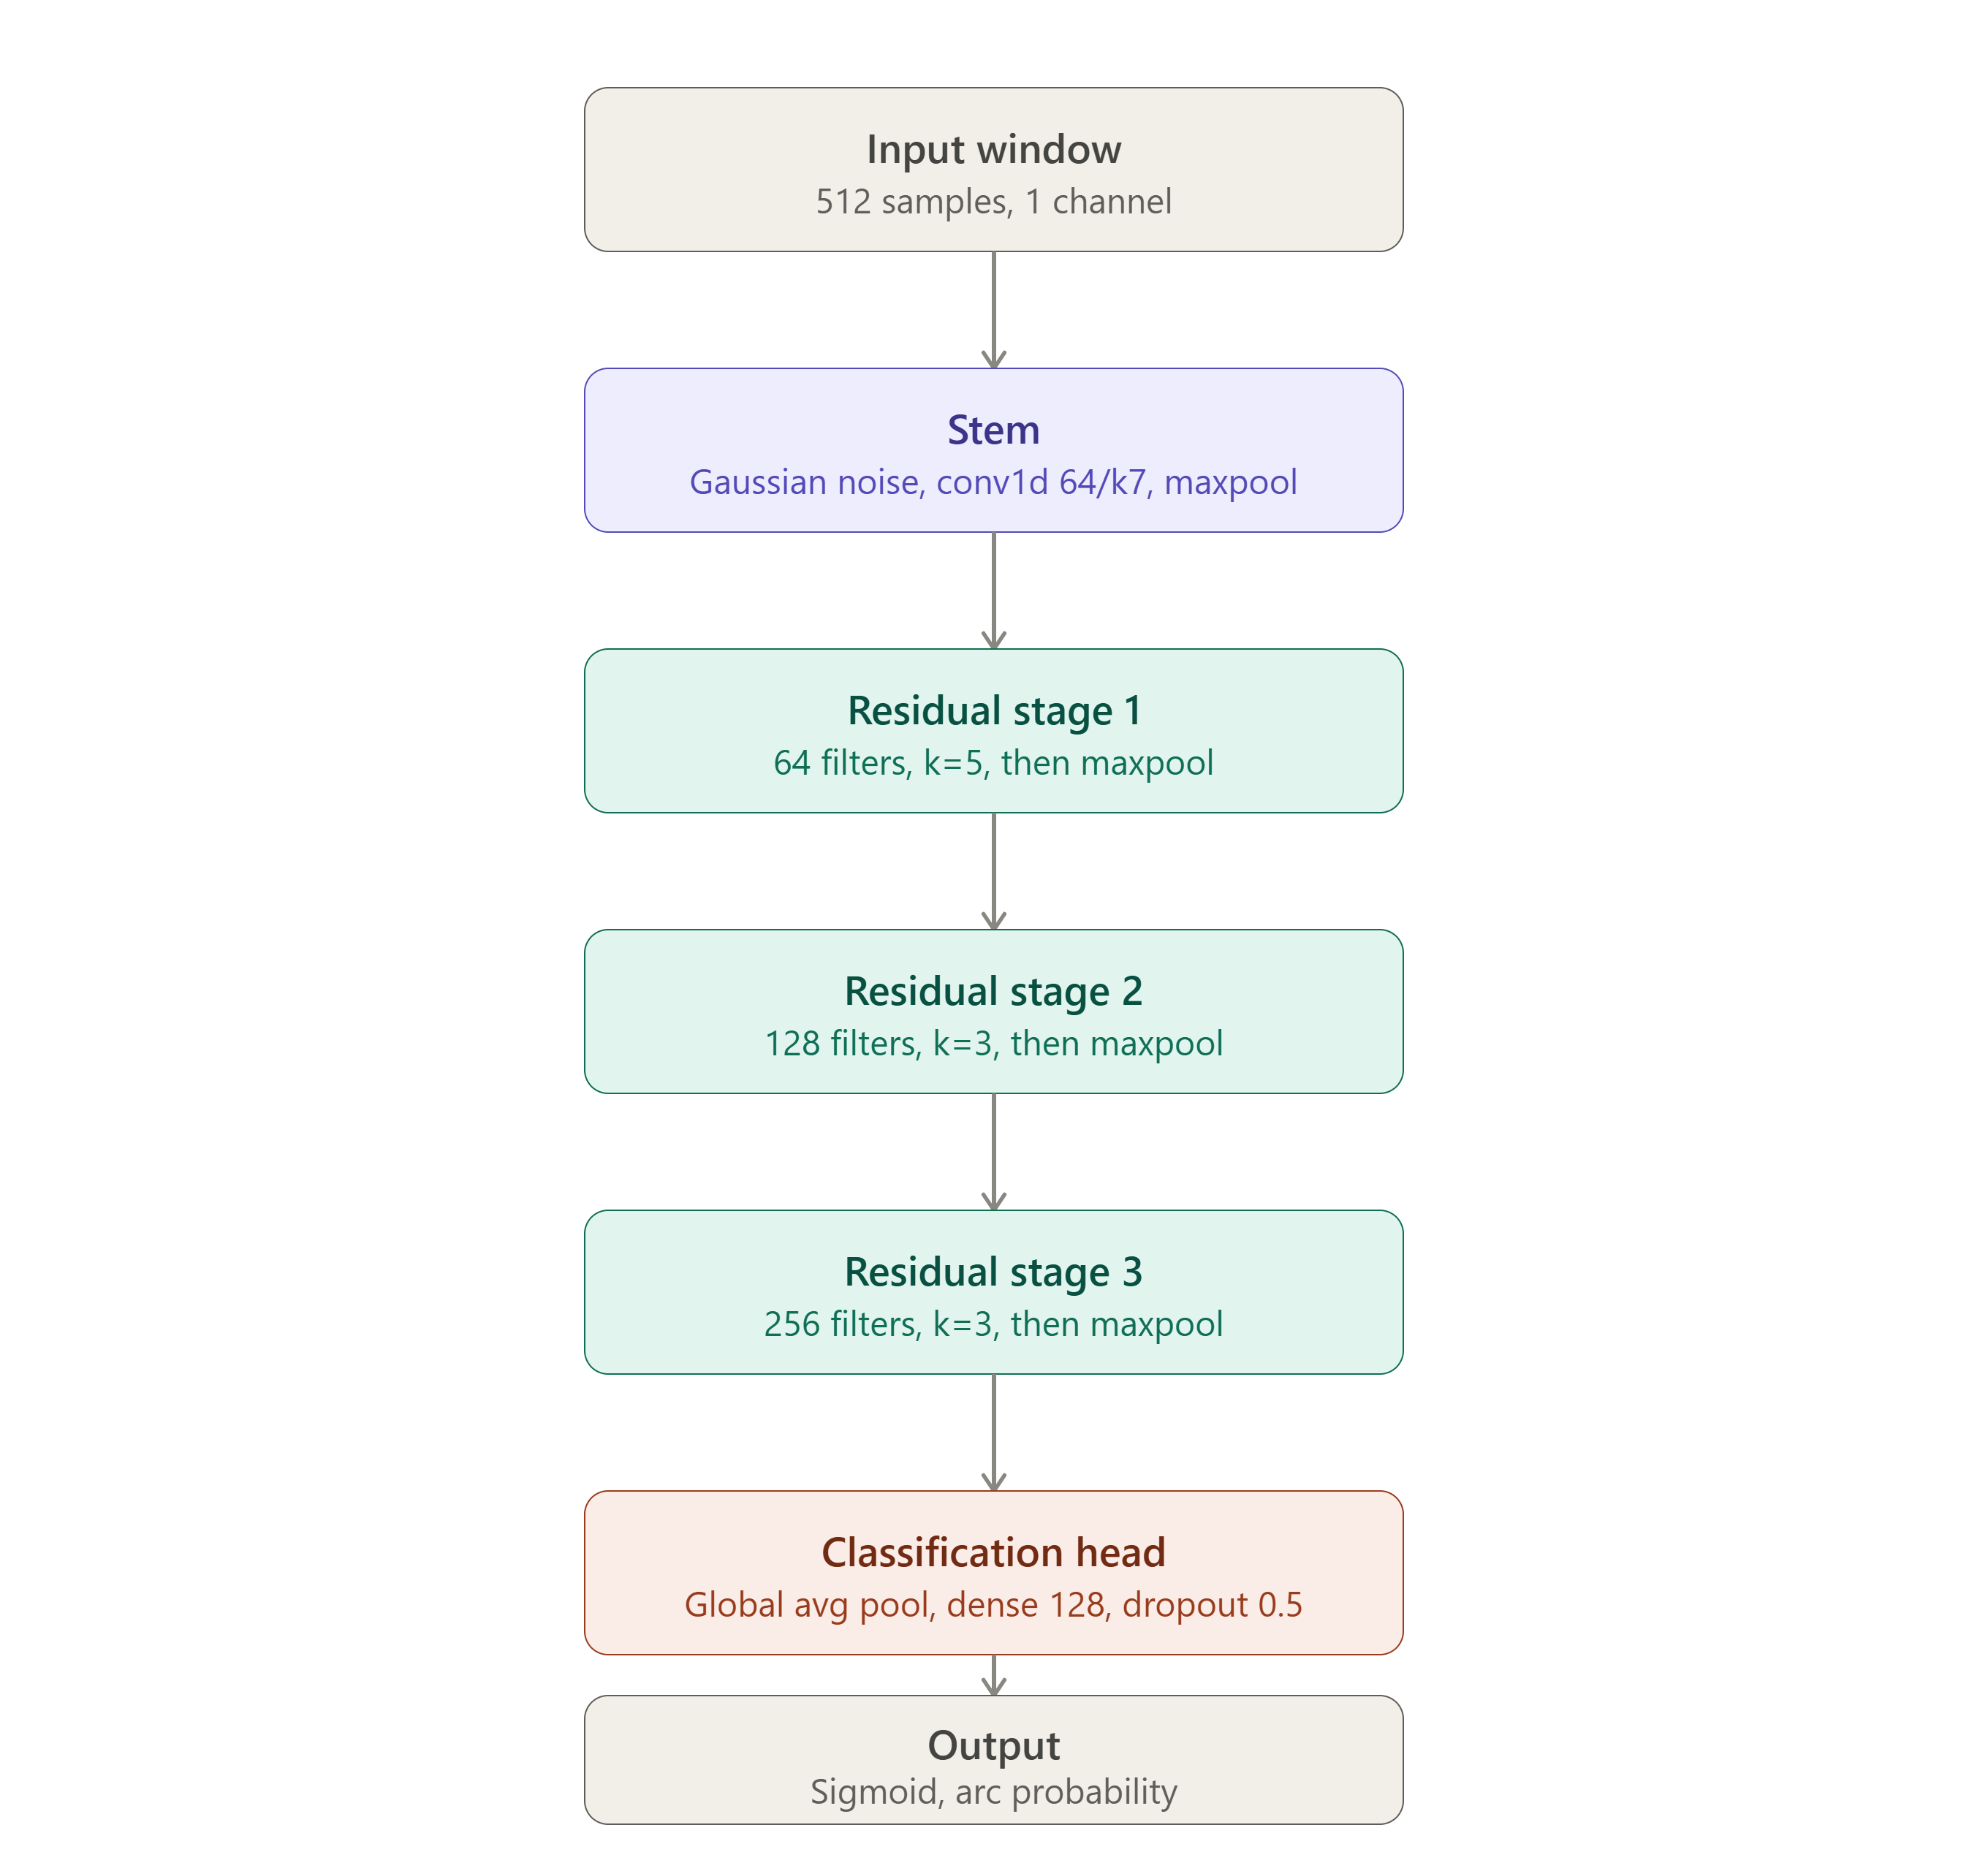

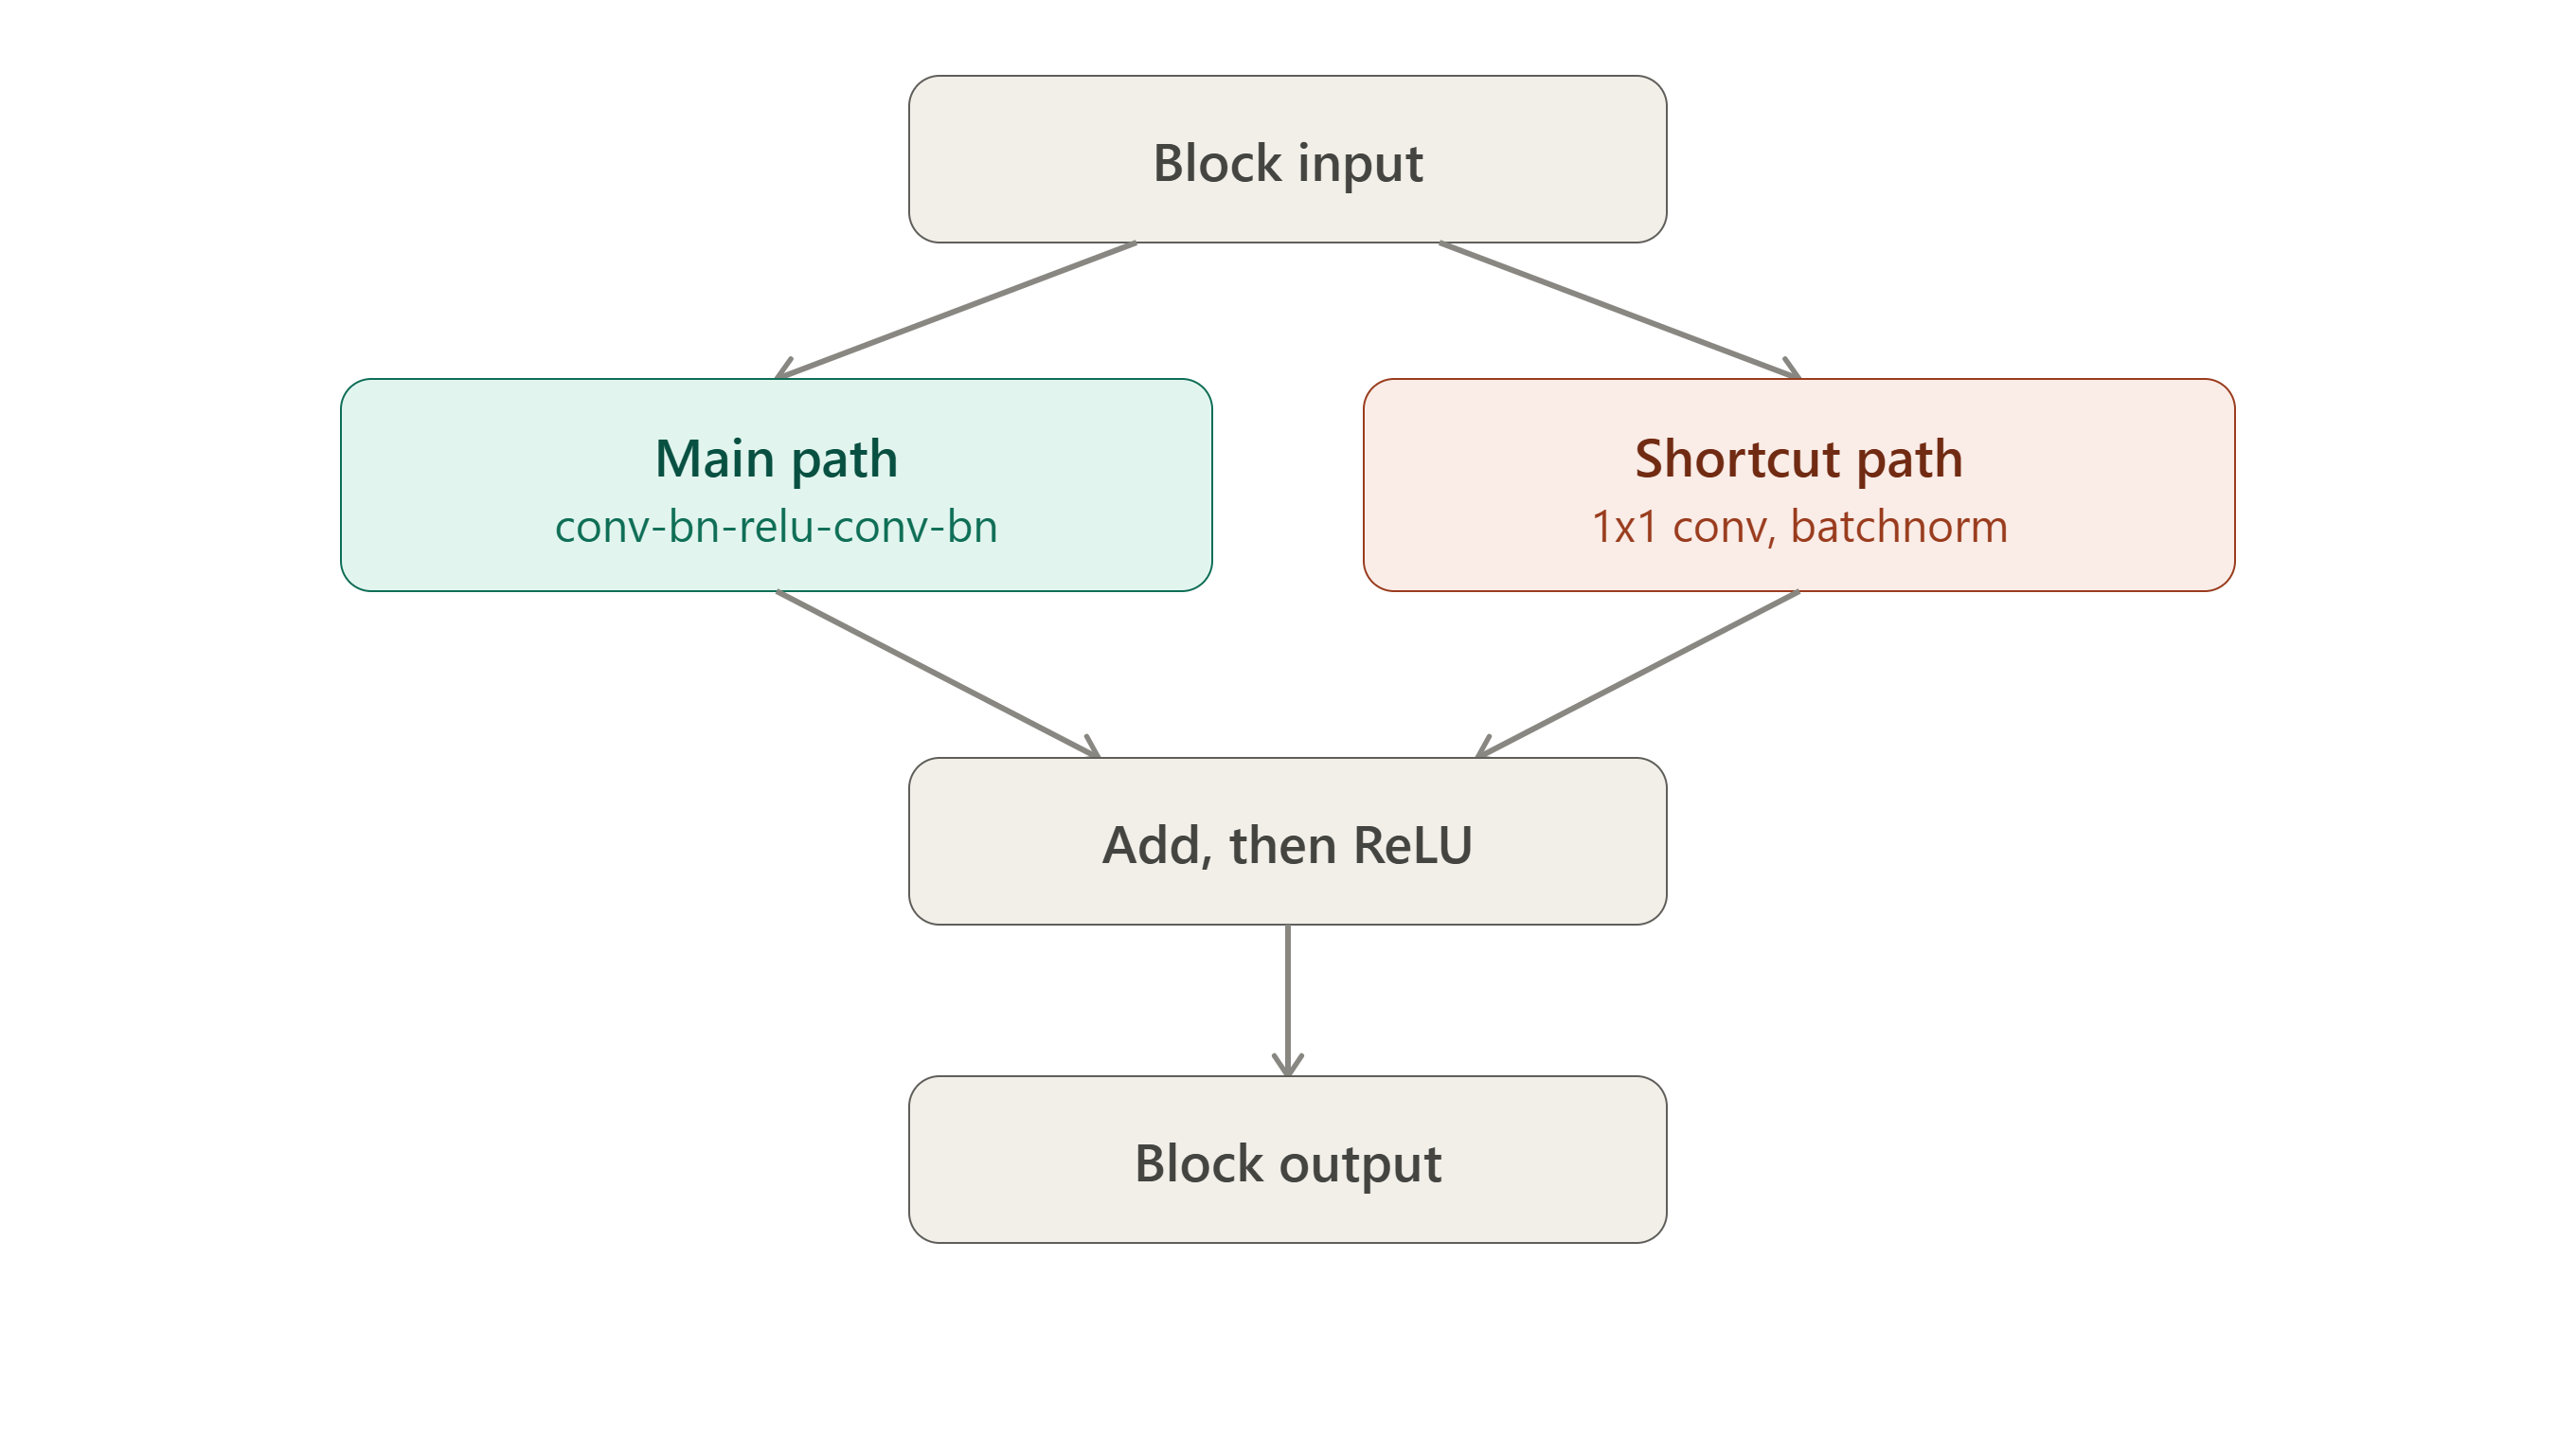

In [ ]:
import os
import unicodedata
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

BASE_PATH = '/content/drive/MyDrive/Arc_Fault_Training/'
LABEL_FILE = os.path.join(BASE_PATH, 'Data_label.xlsx')

if 'df_labels' not in globals():
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    df_labels = pd.read_excel(LABEL_FILE)

    def clean_str(s):
        if not isinstance(s, str):
            return s
        return ''.join(ch for ch in s if unicodedata.category(ch) != 'Cf').strip()

    df_labels['data_path'] = df_labels['data_path'].apply(clean_str)
    df_labels['data_name'] = df_labels['data_name'].apply(clean_str)

WINDOW_SIZE = 512
STRIDE = 256

def extract_normalized_data(target_model):
    X_temp, y_temp = [], []
    data_file_path = os.path.join(BASE_PATH, f'{target_model}.xlsx')
    if not os.path.exists(data_file_path):
        print(f"Warning: {target_model}.xlsx not found. Skipping...")
        return [], []
    df_dict = pd.read_excel(data_file_path, sheet_name=None, header=None)
    df_model_labels = df_labels[df_labels['data_path'] == target_model]
    for idx, row in df_model_labels.iterrows():
        raw_name = str(row['data_name']).strip()
        try:
            prefix, trial_part = raw_name.split('_')
            sheet_name = prefix.strip()
            col_idx = int(''.join(filter(str.isdigit, trial_part)))
        except Exception:
            continue
        if sheet_name not in df_dict:
            continue
        try:
            signal = pd.to_numeric(df_dict[sheet_name].iloc[:, col_idx], errors='coerce').dropna().values
            total_samples = len(signal)
        except Exception:
            continue
        st_no, ed_no = int(row['st_idx_noarc']), int(row['ed_idx_noarc'])
        st_ar, ed_ar = int(row['st_idx_arc']), int(row['ed_idx_arc'])
        has_arc = not (st_ar == -1 and ed_ar == -1)
        if ed_no == -1: ed_no = total_samples
        if ed_ar == -1: ed_ar = total_samples
        st_no, ed_no = max(0, min(st_no, total_samples)), max(0, min(ed_no, total_samples))
        st_ar, ed_ar = max(0, min(st_ar, total_samples)), max(0, min(ed_ar, total_samples))

        def normalize_window(win):
            return (win - np.mean(win)) / (np.std(win) + 1e-8)

        if st_no < ed_no and (ed_no - st_no) >= WINDOW_SIZE:
            for start in range(st_no, ed_no - WINDOW_SIZE + 1, STRIDE):
                window = signal[start: start + WINDOW_SIZE]
                X_temp.append(normalize_window(window))
                y_temp.append(0)
        if has_arc and st_ar < ed_ar and (ed_ar - st_ar) >= WINDOW_SIZE:
            for start in range(st_ar, ed_ar - WINDOW_SIZE + 1, STRIDE):
                window = signal[start: start + WINDOW_SIZE]
                X_temp.append(normalize_window(window))
                y_temp.append(1)
    return X_temp, y_temp

print("Extracting ALL clean training data (now including EMI + EMI_test)...")
ALL_CLEAN_FILES = ['Model_A', 'Model_B', 'Model_C', 'Model_D', 'NewVacuumCleaner',
                    'ElectronicDimmer', 'EMI', 'EMI_test']
X_list, y_list = [], []
for model_name in ALL_CLEAN_FILES:
    print(f"   -> Processing {model_name}...")
    x_t, y_t = extract_normalized_data(model_name)
    print(f"      {len(x_t)} windows, classes: {sorted(set(y_t))}")
    X_list.extend(x_t)
    y_list.extend(y_t)

X_all = np.expand_dims(np.array(X_list), axis=-1)
y_all = np.array(y_list)
print(f"\nTotal windows: {X_all.shape[0]}")

X_train, X_monitor, y_train, y_monitor = train_test_split(
    X_all, y_all, test_size=0.10, stratify=y_all, random_state=42
)
print(f"Train: {X_train.shape[0]}, Monitor-only split: {X_monitor.shape[0]}")

class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(np.unique(y_train), class_weights_arr)}
print(f"Class weights: {class_weight_dict}")

def resnet_block(input_tensor, filters, kernel_size=5):
    x = layers.Conv1D(filters, kernel_size, padding='same')(input_tensor)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    shortcut = layers.Conv1D(filters, 1, padding='same')(input_tensor)
    shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

input_tensor = Input(shape=(WINDOW_SIZE, 1))
x = layers.GaussianNoise(0.05)(input_tensor)
x = layers.Conv1D(64, 7, padding='same', activation='relu')(x)
x = layers.MaxPooling1D(2)(x)
x = resnet_block(x, filters=64, kernel_size=5)
x = layers.MaxPooling1D(2)(x)
x = resnet_block(x, filters=128, kernel_size=3)
x = layers.MaxPooling1D(2)(x)
x = resnet_block(x, filters=256, kernel_size=3)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output_tensor = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=input_tensor, outputs=output_tensor)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(BASE_PATH, 'final_model_v2.keras'),
        monitor='val_auc', mode='max', save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=10, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
]

print("\nTraining final model v2 (with EMI + EMI_test)...")
history = model.fit(
    X_train, y_train, epochs=50, batch_size=64,
    validation_data=(X_monitor, y_monitor),
    class_weight=class_weight_dict,
    callbacks=callbacks, verbose=1
)

best_epoch = int(np.argmax(history.history['val_auc']) + 1)
print(f"\nBest epoch: {best_epoch} (val_auc={max(history.history['val_auc']):.4f})")
print("Saved to final_model_v2.keras")

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Monitor-split Accuracy')
plt.axvline(best_epoch - 1, color='green', linestyle=':', label='Best epoch')
plt.title('Final model v2: Accuracy'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Val Loss')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.axvline(best_epoch - 1, color='green', linestyle=':', label='Best epoch')
plt.title('Final model v2: Loss vs AUC'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Test for final model V2

In [ ]:
# =====================================================================
# PHASE 7: BLIND CONFIRMATION TEST
# Evaluates final_model.keras against the three files that have NOT
# influenced any decision so far: EMI_test (no-arc only, tests false-
# positive/nuisance-immunity behavior on a noise type never trained
# on), and ElectronicDimmer_test / ElectronicDimmer_test2 (both
# classes, independent recording sessions). This is the one number to
# report as the honest final result -- no more tuning after this.
# =====================================================================

import os
import unicodedata
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

BASE_PATH = '/content/drive/MyDrive/Arc_Fault_Training/'
LABEL_FILE = os.path.join(BASE_PATH, 'Data_label.xlsx')
MODEL_PATH = os.path.join(BASE_PATH, 'final_model_v2.keras')

if 'df_labels' not in globals():
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    df_labels = pd.read_excel(LABEL_FILE)

    def clean_str(s):
        if not isinstance(s, str):
            return s
        return ''.join(ch for ch in s if unicodedata.category(ch) != 'Cf').strip()

    df_labels['data_path'] = df_labels['data_path'].apply(clean_str)
    df_labels['data_name'] = df_labels['data_name'].apply(clean_str)

WINDOW_SIZE = 512
STRIDE = 256

print("Loading final model...")
model = tf.keras.models.load_model(MODEL_PATH)

def extract_normalized_data(target_model):
    X_temp, y_temp = [], []
    data_file_path = os.path.join(BASE_PATH, f'{target_model}.xlsx')
    if not os.path.exists(data_file_path):
        print(f"Warning: {target_model}.xlsx not found. Skipping...")
        return [], []
    df_dict = pd.read_excel(data_file_path, sheet_name=None, header=None)
    df_model_labels = df_labels[df_labels['data_path'] == target_model]
    for idx, row in df_model_labels.iterrows():
        raw_name = str(row['data_name']).strip()
        try:
            prefix, trial_part = raw_name.split('_')
            sheet_name = prefix.strip()
            col_idx = int(''.join(filter(str.isdigit, trial_part)))
        except Exception:
            continue
        if sheet_name not in df_dict:
            continue
        try:
            signal = pd.to_numeric(df_dict[sheet_name].iloc[:, col_idx], errors='coerce').dropna().values
            total_samples = len(signal)
        except Exception:
            continue
        st_no, ed_no = int(row['st_idx_noarc']), int(row['ed_idx_noarc'])
        st_ar, ed_ar = int(row['st_idx_arc']), int(row['ed_idx_arc'])
        has_arc = not (st_ar == -1 and ed_ar == -1)
        if ed_no == -1: ed_no = total_samples
        if ed_ar == -1: ed_ar = total_samples
        st_no, ed_no = max(0, min(st_no, total_samples)), max(0, min(ed_no, total_samples))
        st_ar, ed_ar = max(0, min(st_ar, total_samples)), max(0, min(ed_ar, total_samples))

        def normalize_window(win):
            return (win - np.mean(win)) / (np.std(win) + 1e-8)

        if st_no < ed_no and (ed_no - st_no) >= WINDOW_SIZE:
            for start in range(st_no, ed_no - WINDOW_SIZE + 1, STRIDE):
                window = signal[start: start + WINDOW_SIZE]
                X_temp.append(normalize_window(window))
                y_temp.append(0)
        if has_arc and st_ar < ed_ar and (ed_ar - st_ar) >= WINDOW_SIZE:
            for start in range(st_ar, ed_ar - WINDOW_SIZE + 1, STRIDE):
                window = signal[start: start + WINDOW_SIZE]
                X_temp.append(normalize_window(window))
                y_temp.append(1)
    return X_temp, y_temp

TEST_FILES = ['EMI', 'EMI_test', 'ElectronicDimmer_test', 'ElectronicDimmer_test2']

all_X, all_y, all_source = [], [], []
for f in TEST_FILES:
    print(f"Extracting {f}...")
    x, y = extract_normalized_data(f)
    print(f"   {f}: {len(x)} windows, classes present: {sorted(set(y))}")
    all_X.extend(x)
    all_y.extend(y)
    all_source.extend([f] * len(x))

X_test = np.expand_dims(np.array(all_X), axis=-1)
y_test = np.array(all_y)
source = np.array(all_source)

print(f"\nTotal blind test windows: {len(X_test)}")

y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# --- Per-file results ---
for f in TEST_FILES:
    mask = source == f
    if mask.sum() == 0:
        continue
    yt, yp = y_test[mask], y_pred[mask]
    print(f"\n=== {f} ({mask.sum()} windows) ===")
    if len(set(yt)) < 2:
        acc = (yt == yp).mean()
        print(f"Only one class present (y={yt[0]}). Accuracy: {acc:.4f}")
        if yt[0] == 0:
            print(f"(This is the nuisance-immunity check: {1 - acc:.4f} false-positive rate on unseen noise)")
    else:
        print(classification_report(yt, yp, target_names=['Normal', 'Arc']))
        print("Confusion matrix:\n", confusion_matrix(yt, yp))

# --- Combined result across the two dimmer test files (both classes present) ---
dimmer_mask = np.isin(source, ['ElectronicDimmer_test', 'ElectronicDimmer_test2'])
print(f"\n=== Combined: both ElectronicDimmer test files ({dimmer_mask.sum()} windows) ===")
print(classification_report(y_test[dimmer_mask], y_pred[dimmer_mask], target_names=['Normal', 'Arc']))
print("Confusion matrix:\n", confusion_matrix(y_test[dimmer_mask], y_pred[dimmer_mask]))

# --- Overall combined (all 3 files) ---
print(f"\n=== OVERALL BLIND CONFIRMATION (all {len(X_test)} windows) ===")
overall_acc = (y_test == y_pred).mean()
print(f"Overall accuracy: {overall_acc:.4f}")